In [105]:
from detection_helper import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, map_coordinates
from matplotlib.colors import LogNorm
import numpy.linalg as LA

30-May-26 16:06:52: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
30-May-26 16:06:52: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
30-May-26 16:06:53: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
30-May-26 16:06:53: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
30-May-26 16:06:53: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
30-May-26 16:06:54: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
30-May-26 16:06:54: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
30-May-26 16:06:54: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


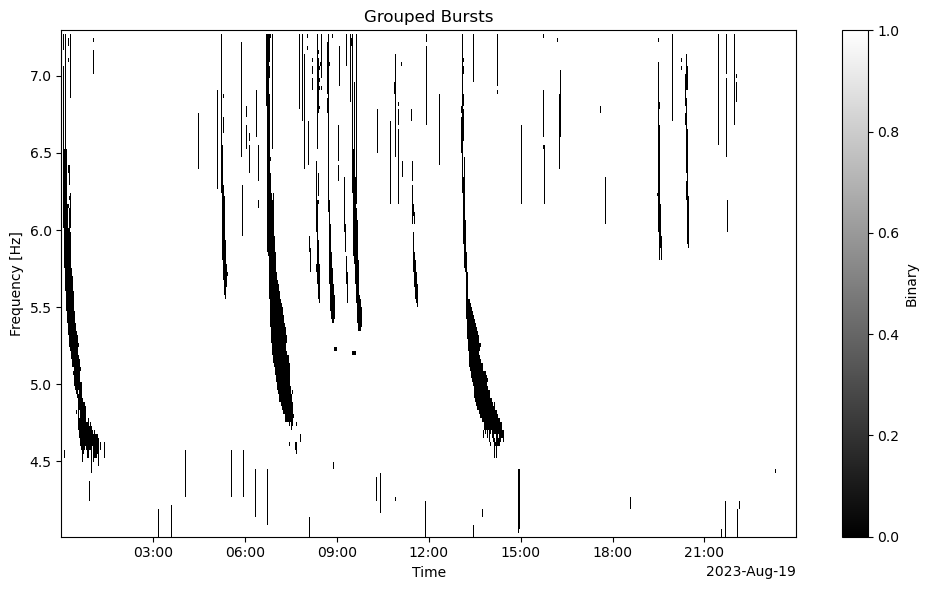

In [3]:
times_arr, freq_arr, data_arr = return_arr('2023-08-19', '2023-08-20')
freq_log, freq_log_exp, data_arr_log = convert_data_log(freq_arr, data_arr)
bmap = bmap_row_mean_loop_new(times_arr=times_arr, full_data=data_arr_log, min_duration=1)
plot_bmap(times_arr, freq_log_exp, bmap)

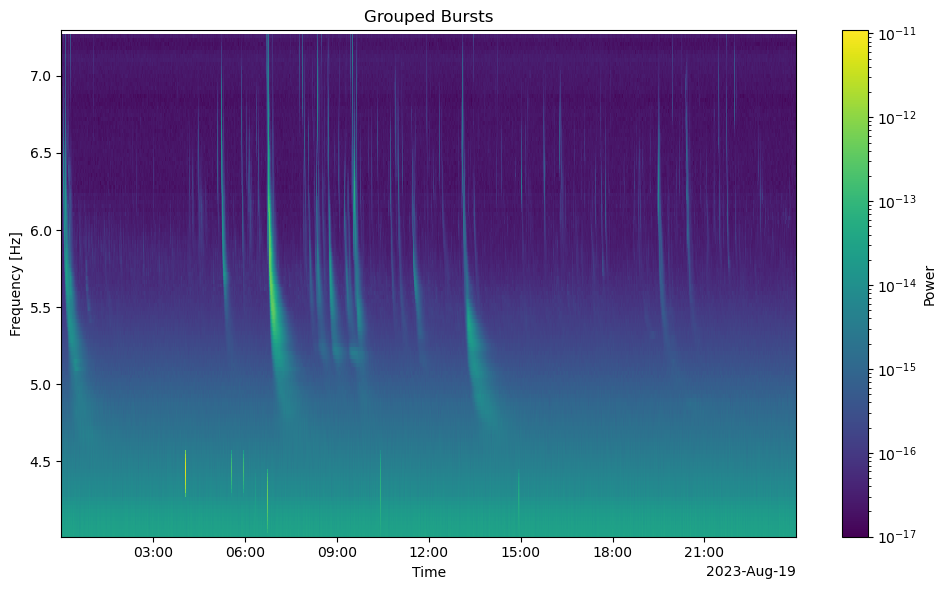

In [5]:
plot_spectrum(times_arr, freq_log_exp, data_arr_log)

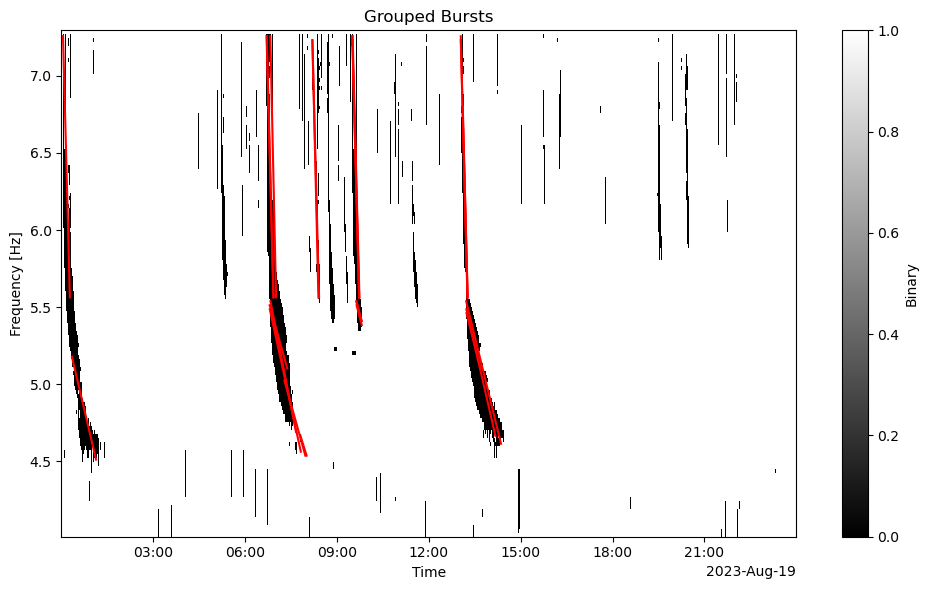

In [7]:
lines = all_lines_day(bmap, times_arr, freq_log_exp, data_arr_log)
plot_bmap(times_arr, freq_log_exp, bmap, lines)

In [23]:
lines

[((60, 142), (126, 27)),
 ((19, 582), (45, 176)),
 ((60, 3568), (126, 3453)),
 ((42, 3799), (58, 3502)),
 ((60, 3564), (126, 3450)),
 ((26, 3945), (59, 3516)),
 ((60, 3610), (126, 3513)),
 ((21, 4026), (57, 3504)),
 ((60, 4322), (125, 4221)),
 ((20, 4102), (39, 3750)),
 ((60, 4333), (125, 4220)),
 ((20, 4123), (25, 4020)),
 ((60, 5005), (126, 4891)),
 ((54, 5049), (59, 4960)),
 ((60, 5007), (126, 4892)),
 ((54, 5049), (59, 4961)),
 ((60, 5012), (126, 4897)),
 ((53, 5051), (58, 4964)),
 ((60, 6828), (125, 6716)),
 ((42, 7049), (56, 6812)),
 ((60, 6831), (126, 6716)),
 ((25, 7299), (57, 6810)),
 ((60, 6832), (108, 6750)),
 ((23, 7393), (59, 6807))]

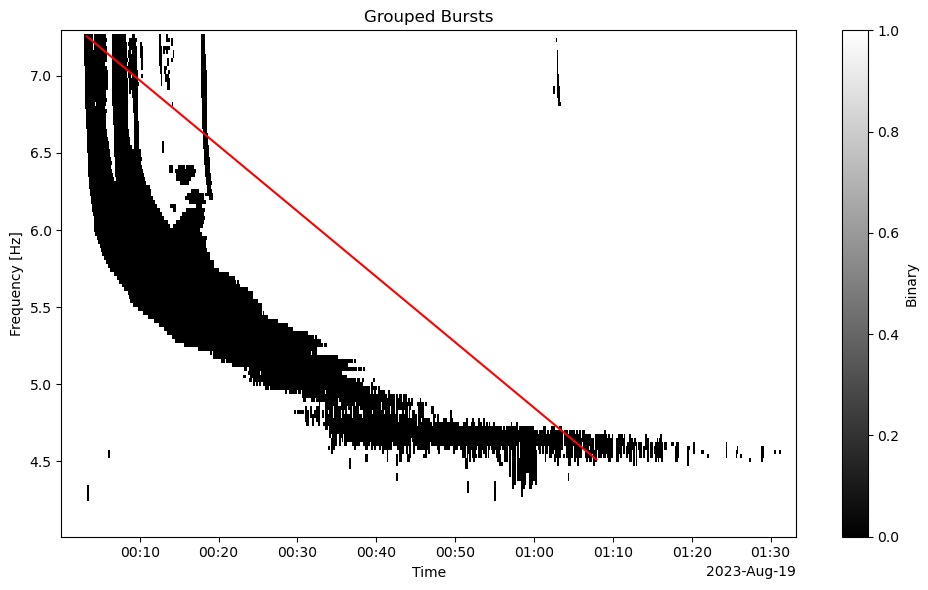

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap[:800].T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

(x0_low, y0_low), (x1_low, y1_low) = lines[1]
(x0_high, y0_high), (x1_high, y1_high) = lines[0]
(x0, y0), (x1, y1) = (x0_low, y0_low), (x1_high, y1_high)

t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import numpy.linalg as LA
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter
import numpy.linalg as LA

def PJcurvature(x,y):
    """
    input  : the coordinate of the three point
    output : the curvature and norm direction
    refer to https://github.com/peijin94/PJCurvature for detail
    """
    t_a = LA.norm([x[1]-x[0],y[1]-y[0]])
    t_b = LA.norm([x[2]-x[1],y[2]-y[1]])

    M = np.array([
        [1, -t_a, t_a**2],
        [1, 0,    0     ],
        [1,  t_b, t_b**2]])

    a = np.matmul(LA.pinv(M),x)
    b = np.matmul(LA.pinv(M),y)

    kappa = 2*(a[2]*b[1]-b[2]*a[1])/(a[1]**2.+b[1]**2.)**(1.5)
    return kappa, [b[1],-a[1]]/np.sqrt(a[1]**2.+b[1]**2.)


def ACBone(img,x,y,x0,y0,n_iter = 200,d_step=0.2,alpha=25,beta=6000,y_gap=90.,blur_sigma=2.5):
        # print((y0[0]),(y0[1]))
        N=int(abs(y0[1]-y0[0])/y_gap)
        N=300
        yy = np.linspace((y0[0]),(y0[1]), 300)
        # print(int(abs(y0[1]-y0[0])/y_gap))
        # print(yy)
        xx = np.linspace((x0[0]),(x0[1]), len(yy))# +  np.random.normal(0, 0.1, len(yy))
        # print("\n[INIT]")
        # print("x0=", x0, "y0=", y0)
        # print("y_gap=", y_gap, "dy=", float(abs(y0[1]-y0[0])))
        # print("N=", len(xx))
        # print("xx head/tail:", xx[:3], xx[-3:])
        # print("yy head/tail:", yy[:3], yy[-3:])
        # print("finite xx?", np.isfinite(xx).all(), "finite yy?", np.isfinite(yy).all())

        # blurred = gaussian_filter(img, sigma=blur_sigma)
        # might be axis sensitive: need different sigma for x and y axis
        blurred = img
        print(len(x))
        print(len(y))
        print(np.gradient(img,axis=1).shape)
        print(np.gradient(img,axis=1))
        print(np.max(np.gradient(img,axis=1)).shape)
        print(np.max(np.gradient(img,axis=1)))

        X, Y = np.meshgrid(x, y)
        # Grad_x = interp2d(x, y, np.gradient(img,axis=1)/(np.max(np.gradient(img,axis=1))), kind='quintic')
        norm_grad_along_x = np.gradient(img,axis=1)/(np.max(np.gradient(img,axis=1)))
        norm_grad_along_y = np.gradient(img,axis=0)/(np.max(np.gradient(img,axis=0)))

        norm_grad_along_x_blur = gaussian_filter(norm_grad_along_x, sigma=blur_sigma)
        norm_grad_along_y_blur = gaussian_filter(norm_grad_along_y, sigma=blur_sigma)
    
        plt.pcolormesh(X, Y, norm_grad_along_x.T, norm=LogNorm())
        plt.title('norm_grad_along_x')
        plt.show()

        plt.pcolormesh(X, Y, norm_grad_along_y.T, norm=LogNorm())
        plt.title('norm_grad_along_y')
        plt.show()   

        norm_grad_along_x_blur = gaussian_filter(norm_grad_along_x, sigma=blur_sigma)
        plt.pcolormesh(X, Y, norm_grad_along_x_blur.T, norm=LogNorm())
        plt.title('norm_grad_along_x_blur')
        plt.show()

        norm_grad_along_y_blur = gaussian_filter(norm_grad_along_y, sigma=blur_sigma)
        plt.pcolormesh(X, Y, norm_grad_along_y_blur.T, norm=LogNorm())
        plt.title('norm_grad_along_y_blur')
        plt.show()   
    
        # Grad_x = interp2d(X, Y, np.gradient(img,axis=1)/(np.max(np.gradient(img,axis=1))), kind='quintic')
        # Grad_x = interp2d(X, Y, norm_grad_along_x, kind='quintic')
        # Grad_x = interp2d(X, Y, norm_grad_along_x, kind='linear')
        # Grad_y = interp2d(x, y, np.gradient(img,axis=0)/(np.max(np.gradient(img,axis=0))), kind='quintic')
        # Grad_y = interp2d(x, y, norm_grad_along_y, kind='quintic')
        # Grad_y = interp2d(X, Y, norm_grad_along_y, kind='linear')

        # plt.pcolormesh(X, Y, Grad_x.T, norm=LogNorm())
        # plt.show()
        # plt.pcolormesh(X, Y, Grad_y.T, norm=LogNorm())
        # plt.show()
        # print('finish iterp2d')


        # Grad_x_blur = interp2d(x, y, np.gradient(blurred,axis=1)/(np.max(np.gradient(blurred,axis=1))), kind='quintic')
        # Grad_y_blur = interp2d(x, y, np.gradient(blurred,axis=0)/(np.max(np.gradient(blurred,axis=0))), kind='quintic')
        print('finish iterp2d blur')

        xx_new = xx
        yy_new = yy

        idx_img=0
        # print(n_iter)
        for step in range(n_iter):
            print('step: ', step)
            kappa_arr = np.zeros(len(xx))
            norm_arr  = np.zeros([len(xx),2])
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # print('xx')
            # print(xx[1:-1])
            # print(xx)
            for idx,val in enumerate(xx[1:-1]):
                # print('idx')
                # print(idx)
                # print('val')
                # print(val)
                ytmp = yy_new[idx:idx+3]
                # print('ytmp')
                # print(ytmp)
                xtmp = xx_new[idx:idx+3]
                # print('xtmp')
                # print(xtmp)
                try: 
                    kappa,norm_l = PJcurvature(xtmp,ytmp)
                    kappa_arr[idx+1] = kappa
                    norm_arr[idx+1,:] = norm_l
                except LinAlgError:
                    pass
                
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # plt.plot(xx_new,kappa_arr)
            # plt.show()
            # plt.plot(xx_new,norm_arr)
            # plt.show()
            
            f_x = beta* kappa_arr*norm_arr[:,0]
            f_x[-1] = -f_x[-2]
            f_x[0] = -f_x[1]
            if step>n_iter/3.5 :
                # xx_new = xx_new+ d_step* (alpha * np.array([Grad_x(xx_new[i],yy_new[i])
                grad_at_xx_new = norm_grad_along_x_blur[]
                xx_new = xx_new + d_step*()
                            for i in np.arange(len(xx_new)))[:,0] + f_x)
            else:
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new)))[:,0] + f_x)

            #print(alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
            #                for i in np.arange(len(xx_new))])[:,0])
            #yy_new = yy_new+ d_step/1000* (alpha * np.array([Grad_y(xx_new[i],yy_new[i])
            #                                            for i in np.arange(len(xx_new))])[:,0])

        img_xy = interp2d(x, y, img, kind='quintic')
        flux = np.array([img_xy(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0]

        return xx_new,yy_new,flux

SyntaxError: unmatched ']' (1439757116.py, line 150)

In [85]:
def get_gradient_on_spectrum_line(data_img, line, n_points=50, smooth_sigma=2):
    """
    data_img shape: [time_index, freq_index]
    example: data_arr_log[:800]

    line format:
    ((freq_idx0, time_idx0), (freq_idx1, time_idx1))
    """

    # line endpoints
    (f0, t0), (f1, t1) = line

    # sample points along the line
    t_line = np.linspace(t0, t1, n_points)
    f_line = np.linspace(f0, f1, n_points)

    t_idx = np.round(t_line).astype(int)
    f_idx = np.round(f_line).astype(int)

    # keep inside image
    t_idx = np.clip(t_idx, 0, data_img.shape[0] - 1)
    f_idx = np.clip(f_idx, 0, data_img.shape[1] - 1)

    # use original spectrum values
    img = data_img.astype(float)

    # remove nan/inf before smoothing
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    # smooth the original spectrum
    img_smooth = gaussian_filter(img, sigma=smooth_sigma)

    # gradient
    grad_time = np.gradient(img_smooth, axis=0)
    grad_freq = np.gradient(img_smooth, axis=1)

    gx = grad_time[t_idx, f_idx]
    gy = grad_freq[t_idx, f_idx]

    return t_idx, f_idx, gx, gy

In [87]:
img_original = data_arr_log[:800]

upper_line = lines[0]
lower_line = lines[1]

t_upper, f_upper, gx_upper, gy_upper = get_gradient_on_spectrum_line(
    data_img=img_original,
    line=upper_line,
    n_points=50,
    smooth_sigma=2
)

t_lower, f_lower, gx_lower, gy_lower = get_gradient_on_spectrum_line(
    data_img=img_original,
    line=lower_line,
    n_points=50,
    smooth_sigma=2
)

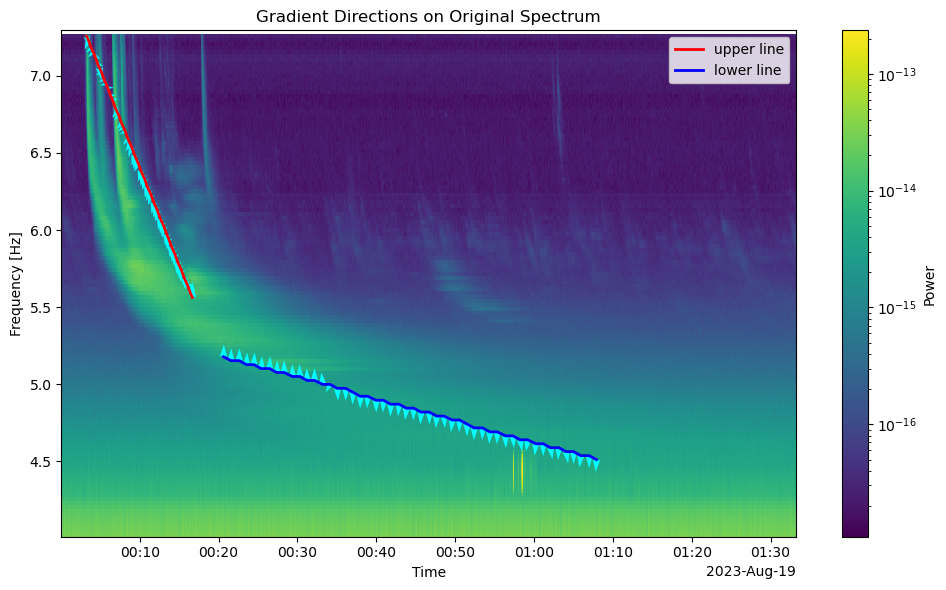

In [91]:
plot_two_lines_with_gradient_arrows(
    data_arr_log, times_arr, freq_log_exp,
    t_upper, f_upper, gx_upper, gy_upper,
    t_lower, f_lower, gx_lower, gy_lower
)

In [117]:
grad_freq = np.gradient(img, axis=1)
grad_time = np.gradient(img, axis=0)

In [119]:
grad_freq

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [121]:
grad_time

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [147]:
img_original_with_nan = data_arr_log[:800].astype(float)
img_original_with_nan

array([[3.47190572e-14, 3.26354375e-14, 3.04249728e-14, ...,
        1.90691369e-17, 2.73608831e-17,            nan],
       [3.21049001e-14, 3.02265164e-14, 2.82337748e-14, ...,
        1.75848126e-17, 2.20327679e-17,            nan],
       [2.74775133e-14, 2.60055005e-14, 2.44438733e-14, ...,
        2.00262130e-17, 2.88809780e-17,            nan],
       ...,
       [2.58729178e-14, 2.43520227e-14, 2.27385385e-14, ...,
        2.17247325e-17, 2.52847921e-17,            nan],
       [3.05754398e-14, 2.87518049e-14, 2.68171546e-14, ...,
        2.55493790e-17, 3.54671853e-17,            nan],
       [3.02749193e-14, 2.84435154e-14, 2.65006235e-14, ...,
        1.79080003e-17, 2.57804371e-17,            nan]])

In [149]:
img = np.nan_to_num(img_original_with_nan, nan=0.0)
img

array([[3.47190572e-14, 3.26354375e-14, 3.04249728e-14, ...,
        1.90691369e-17, 2.73608831e-17, 0.00000000e+00],
       [3.21049001e-14, 3.02265164e-14, 2.82337748e-14, ...,
        1.75848126e-17, 2.20327679e-17, 0.00000000e+00],
       [2.74775133e-14, 2.60055005e-14, 2.44438733e-14, ...,
        2.00262130e-17, 2.88809780e-17, 0.00000000e+00],
       ...,
       [2.58729178e-14, 2.43520227e-14, 2.27385385e-14, ...,
        2.17247325e-17, 2.52847921e-17, 0.00000000e+00],
       [3.05754398e-14, 2.87518049e-14, 2.68171546e-14, ...,
        2.55493790e-17, 3.54671853e-17, 0.00000000e+00],
       [3.02749193e-14, 2.84435154e-14, 2.65006235e-14, ...,
        1.79080003e-17, 2.57804371e-17, 0.00000000e+00]])

In [936]:
img_original_with_nan = data_arr_log[:800].astype(float)
img = np.nan_to_num(img_original_with_nan, nan=0.0)

blur_sigma = 2.5

grad_freq = np.gradient(img, axis=1)   # frequency-index direction
grad_time = np.gradient(img, axis=0)   # time-index direction

norm_grad_freq = grad_freq / np.max(np.abs(grad_freq))
norm_grad_time = grad_time / np.max(np.abs(grad_time))

norm_grad_freq_blur = gaussian_filter(norm_grad_freq, sigma=blur_sigma)
norm_grad_time_blur = gaussian_filter(norm_grad_time, sigma=blur_sigma)
# norm_grad_freq_blur = norm_grad_freq
# norm_grad_time_blur = norm_grad_time

print("img shape:", img.shape)
print("norm_grad_freq_blur shape:", norm_grad_freq_blur.shape)
print("norm_grad_time_blur shape:", norm_grad_time_blur.shape)

img shape: (800, 128)
norm_grad_freq_blur shape: (800, 128)
norm_grad_time_blur shape: (800, 128)


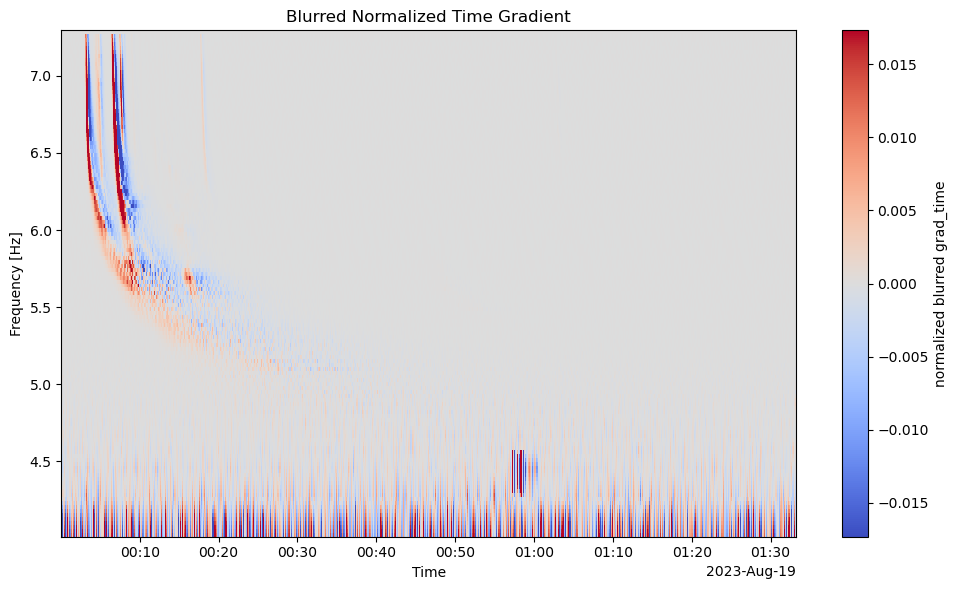

In [163]:
# without gaussian_filter

v = np.nanpercentile(np.abs(norm_grad_time_blur), 99)
if v == 0:
    v = 1

fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(
    times_arr[:800],
    freq_log_exp,
    norm_grad_time_blur.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)

plt.colorbar(p, ax=ax, label="normalized blurred grad_time")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.title("Blurred Normalized Time Gradient")
plt.tight_layout()
plt.show()

In [209]:
sorted_arr_desc = np.sort(np.abs(norm_grad_time_blur).flatten())[::-1]
sorted_arr_desc

array([7.83547898e-02, 7.71615926e-02, 7.42228765e-02, ...,
       1.27897341e-10, 9.12258377e-11, 7.41683433e-11])

In [207]:
np.max(np.abs(norm_grad_time_blur).flatten() )

0.07835478980663833

In [229]:
np.mean(np.abs(norm_grad_time_blur).flatten() )

0.00033492001830112423

0.005547946384798224


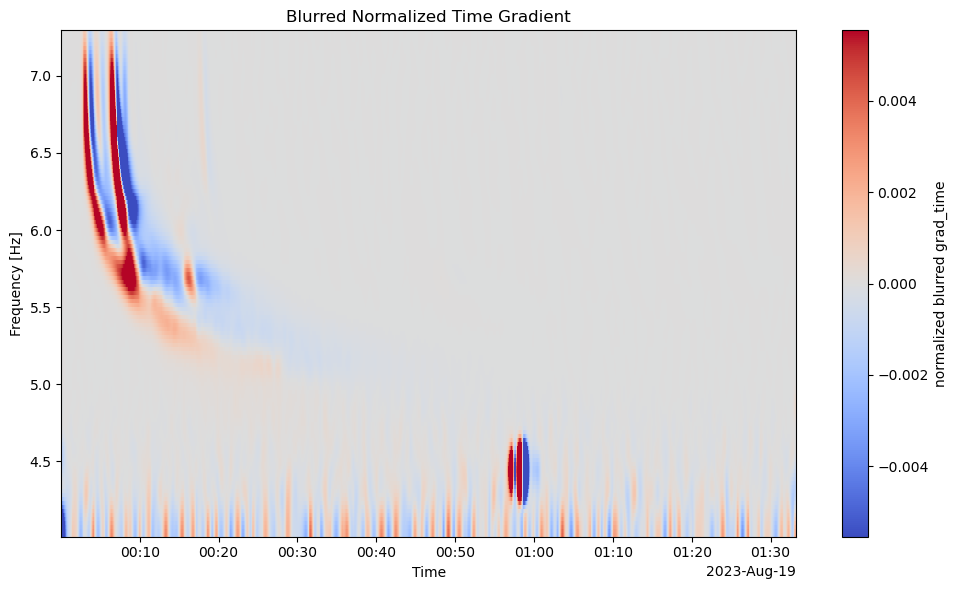

In [233]:
# with gaussian_filter: smoothing the curve

v = np.nanpercentile(np.abs(norm_grad_time_blur), 99)
print(v)

fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(
    times_arr[:800],
    freq_log_exp,
    norm_grad_time_blur.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)

plt.colorbar(p, ax=ax, label="normalized blurred grad_time")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.title("Blurred Normalized Time Gradient")
plt.tight_layout()
plt.show()

0.03909477968177185


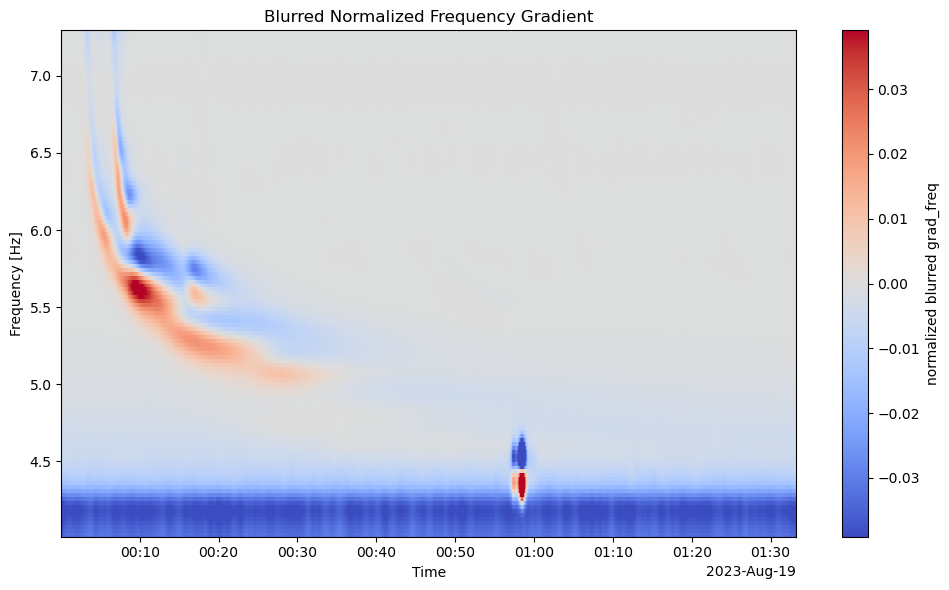

In [237]:
v = np.nanpercentile(np.abs(norm_grad_freq_blur), 99)
print(v)

fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(
    times_arr[:800],
    freq_log_exp,
    norm_grad_freq_blur.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)

plt.colorbar(p, ax=ax, label="normalized blurred grad_freq")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.title("Blurred Normalized Frequency Gradient")
plt.tight_layout()
plt.show()

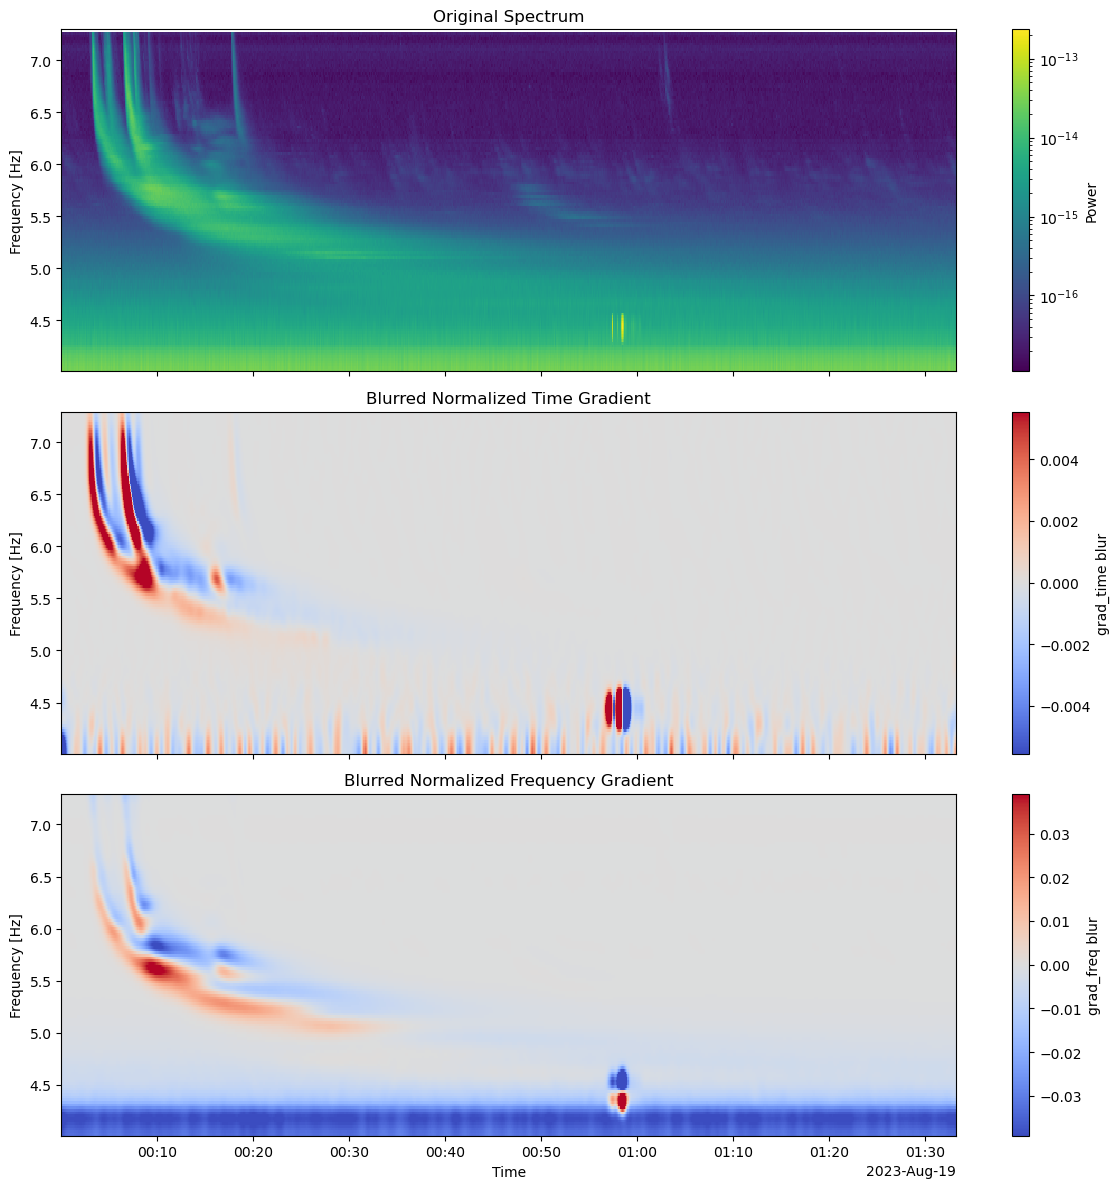

In [223]:
# original spectrum
Z_spec = data_arr_log[:800].T.astype(float)
Z_spec = np.nan_to_num(Z_spec, nan=0.0, posinf=0.0, neginf=0.0)

# color range for gradients
v_time = np.nanpercentile(np.abs(norm_grad_time_blur), 99)
v_freq = np.nanpercentile(np.abs(norm_grad_freq_blur), 99)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# 1. original spectrum
p0 = axes[0].pcolormesh(
    times_arr[:800],
    freq_log_exp,
    Z_spec,
    shading="auto",
    norm=LogNorm()
)
fig.colorbar(p0, ax=axes[0], label="Power")
axes[0].set_ylabel("Frequency [Hz]")
axes[0].set_title("Original Spectrum")

# 2. blurred time gradient
p1 = axes[1].pcolormesh(
    times_arr[:800],
    freq_log_exp,
    norm_grad_time_blur.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v_time, vcenter=0, vmax=v_time)
)
fig.colorbar(p1, ax=axes[1], label="grad_time blur")
axes[1].set_ylabel("Frequency [Hz]")
axes[1].set_title("Blurred Normalized Time Gradient")

# 3. blurred frequency gradient
p2 = axes[2].pcolormesh(
    times_arr[:800],
    freq_log_exp,
    norm_grad_freq_blur.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v_freq, vcenter=0, vmax=v_freq)
)
fig.colorbar(p2, ax=axes[2], label="grad_freq blur")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Frequency [Hz]")
axes[2].set_title("Blurred Normalized Frequency Gradient")

plt.tight_layout()
plt.show()

In [269]:
def make_time_gradient_image(data_img, blur_sigma=2.5):
    """
    Make a blurred time-gradient image.

    data_img should have shape:
        [time_index, freq_index]

    Example:
        data_img = data_arr_log[:800]
    """

    # make a copy as float
    img = data_img.astype(float)

    # remove bad values
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    # gradient along time direction
    grad_time = np.gradient(img, axis=0)

    # normalize so values are not too huge
    max_value = np.max(np.abs(grad_time))

    if max_value == 0:
        max_value = 1

    norm_grad_time = grad_time / max_value

    # smooth the gradient image
    norm_grad_time_blur = gaussian_filter(norm_grad_time, sigma=blur_sigma)

    return img, norm_grad_time_blur

In [271]:
img_original_with_nan.shape

(800, 128)

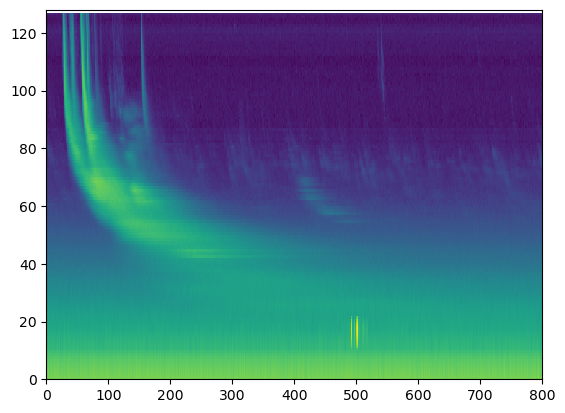

In [273]:
plt.pcolormesh(img_original_with_nan.T, norm=LogNorm())

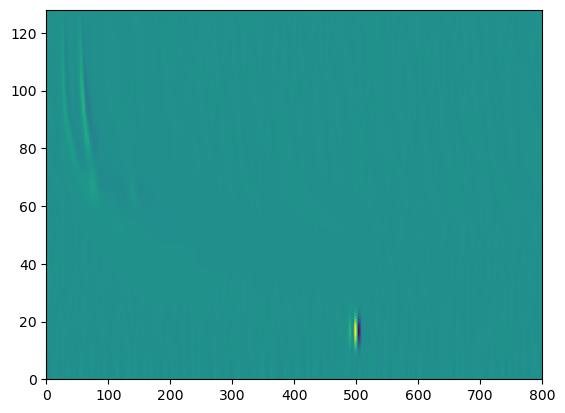

In [275]:
plt.pcolormesh(norm_grad_time_blur.T, norm=TwoSlopeNorm(0))

## Transition points based on sign chage

In [387]:
def find_transition_points(grad_img, threshold=1e-4):
    # Scan left to right through the gradient image.
    # grad_img shape: [time_index, freq_index]
    # Returns 3 lists of points: pos_to_zero_points, zero_to_neg_points, pos_to_neg_points
    
    pos_to_zero_points = []
    zero_to_neg_points = []
    pos_to_neg_points = []

    n_time = grad_img.shape[0]
    n_freq = grad_img.shape[1]

    for freq_idx in range(n_freq):
        # move left to right in time
        for time_idx in range(n_time - 1):
            value_now = grad_img[time_idx, freq_idx]
            value_next = grad_img[time_idx + 1, freq_idx]

            if value_now > threshold:
                sign_now = 1
            elif value_now < -threshold:
                sign_now = -1
            else:
                sign_now = 0

            if value_next > threshold:
                sign_next = 1
            elif value_next < -threshold:
                sign_next = -1
            else:
                sign_next = 0

            # positive -> zero
            if sign_now == 1 and sign_next == 0:
                pos_to_zero_points.append((time_idx + 1, freq_idx))

            # zero -> negative
            if sign_now == 0 and sign_next == -1:
                zero_to_neg_points.append((time_idx + 1, freq_idx))

            # positive -> negative
            if sign_now == 1 and sign_next == -1:
                pos_to_neg_points.append((time_idx + 1, freq_idx))

    return pos_to_zero_points, zero_to_neg_points, pos_to_neg_points

In [389]:
pos_to_zero_points_time, zero_to_neg_points_time, pos_to_neg_points_time = find_transition_points(
    norm_grad_time_blur,
    threshold=5e-3
)

print("number of pos -> 0 points:", len(pos_to_zero_points_time))
print("number of 0 -> neg points:", len(zero_to_neg_points_time))
print("number of pos -> neg points:", len(pos_to_neg_points_time))

number of pos -> 0 points: 127
number of 0 -> neg points: 85
number of pos -> neg points: 0


In [425]:
def plot_transition_points_on_spectrum(
    data_arr_log,
    times_arr,
    freq_log_exp,
    pos_to_zero_points,
    zero_to_neg_points,
    pos_to_neg_points
):


    fig, ax = plt.subplots(figsize=(12, 6))

    # original spectrum
    Z = data_arr_log[:800].T.astype(float)
    Z = np.nan_to_num(Z, nan=0.0)

    p = ax.pcolormesh(
        times_arr[:800],
        freq_log_exp,
        Z,
        shading="auto",
        norm=LogNorm()
    )
    plt.colorbar(p, ax=ax, label="Power")

    # convert point lists into arrays for plotting
    if len(pos_to_zero_points) > 0:
        time_idx1 = [points[0] for points in pos_to_zero_points]
        freq_idx1 = [points[1] for points in pos_to_zero_points]

        ax.scatter(
            times_arr[:800][time_idx1],
            freq_log_exp[freq_idx1],
            s=8,
            color="red",
            label="pos -> 0"
        )

    if len(zero_to_neg_points) > 0:
        time_idx2 = [points[0] for points in zero_to_neg_points]
        freq_idx2 = [points[1] for points in zero_to_neg_points]

        ax.scatter(
            times_arr[:800][time_idx2],
            freq_log_exp[freq_idx2],
            s=8,
            color="blue",
            label="0 -> neg"
        )

    if len(pos_to_neg_points) > 0:
        time_idx3 = [points[0] for points in pos_to_neg_points]
        freq_idx2 = [points[1] for points in pos_to_neg_points]

        ax.scatter(
            times_arr[:800][time_idx3],
            freq_log_exp[freq_idx2],
            s=10,
            color="yellow",
            marker="x",
            label="pos -> neg "
        )

    plt.xlabel("Time")
    plt.ylabel("Frequency [Hz]")
    plt.title("Transition Points on Original Spectrum")
    plt.legend()
    plt.tight_layout()
    plt.show()

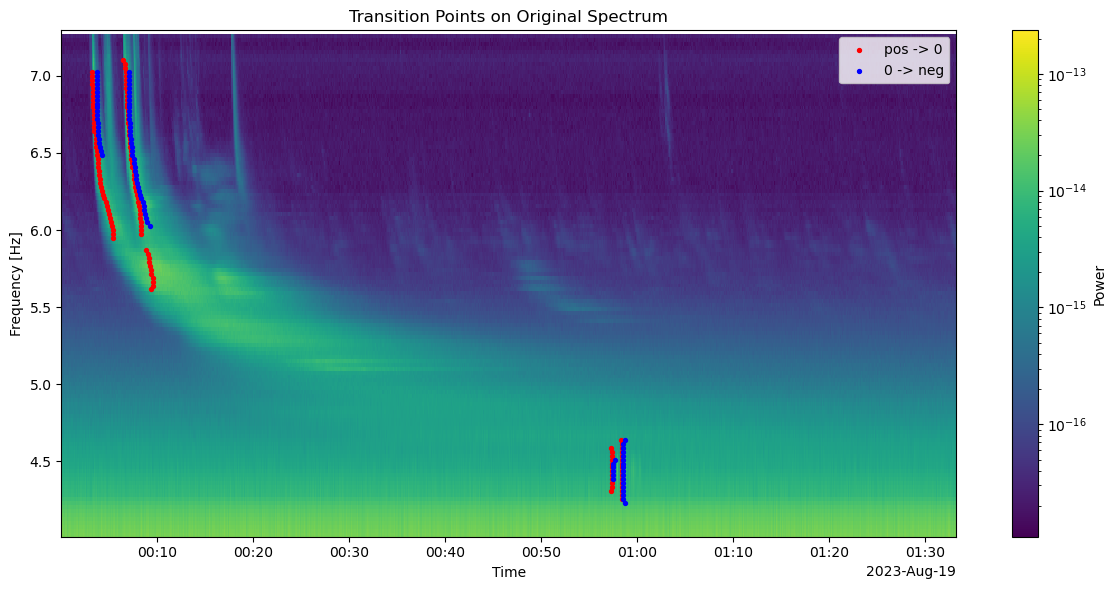

In [427]:
plot_transition_points_on_spectrum(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    pos_to_zero_points=pos_to_zero_points_time,
    zero_to_neg_points=zero_to_neg_points_time,
    pos_to_neg_points=pos_to_neg_points_time
)

In [431]:
pos_to_zero_points_freq, zero_to_neg_points_freq, pos_to_neg_points_freq = find_transition_points(
    norm_grad_freq_blur,
    threshold=5e-3
)

print("number of pos -> 0 points:", len(pos_to_zero_points_freq))
print("number of 0 -> neg points:", len(zero_to_neg_points_freq))
print("number of pos -> neg points:", len(pos_to_neg_points_freq))

number of pos -> 0 points: 95
number of 0 -> neg points: 178
number of pos -> neg points: 0


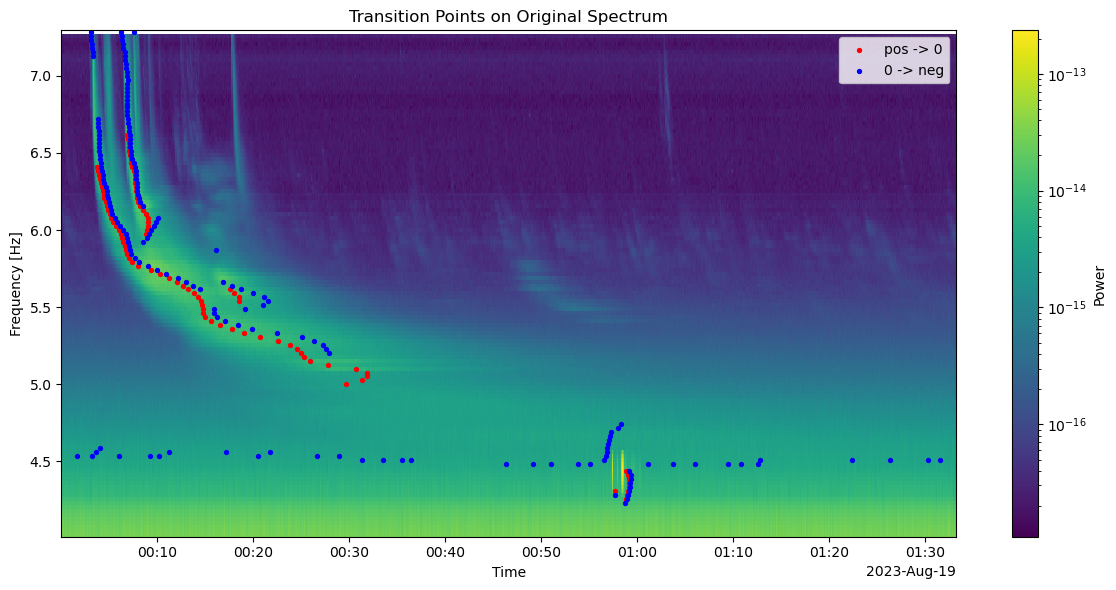

In [433]:
plot_transition_points_on_spectrum(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    pos_to_zero_points=pos_to_zero_points_freq,
    zero_to_neg_points=zero_to_neg_points_freq,
    pos_to_neg_points=pos_to_neg_points_freq
)

In [381]:
pos_to_neg_points_freq[:10]

[]

In [383]:
pos_to_zero_points_all = pos_to_zero_points_time + pos_to_zero_points_freq
zero_to_neg_points_all = zero_to_neg_points_time + zero_to_neg_points_freq
pos_to_neg_points_all = pos_to_neg_points_time + pos_to_neg_points_freq
pos_to_zero_points_all[:10], zero_to_neg_points_all[:10], pos_to_neg_points_all[:10]

([(501, 9),
  (501, 10),
  (491, 11),
  (501, 11),
  (492, 12),
  (501, 12),
  (492, 13),
  (501, 13),
  (492, 14),
  (501, 14)],
 [(503, 8),
  (502, 9),
  (502, 10),
  (502, 11),
  (502, 12),
  (502, 13),
  (493, 14),
  (502, 14),
  (493, 15),
  (502, 15)],
 [])

In [439]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_time_and_freq_transition_points(
    data_arr_log,
    times_arr,
    freq_log_exp,
    pos_to_zero_points_time,
    zero_to_neg_points_time,
    pos_to_neg_points_time,
    pos_to_zero_points_freq,
    zero_to_neg_points_freq,
    pos_to_neg_points_freq,
    pos_to_zero_points_all
):
    fig, ax = plt.subplots(figsize=(12, 6))

    # original spectrum background
    Z = data_arr_log[:800].T.astype(float)
    Z = np.nan_to_num(Z)

    p = ax.pcolormesh(
        times_arr[:800],
        freq_log_exp,
        Z,
        shading="auto",
        norm=LogNorm()
    )

    plt.colorbar(p, ax=ax, label="Power")

    # helper plot func
    def plot_one_point_list(point_list, label_name, marker_type, point_size):
        if len(point_list) == 0:
            return

        time_indices = []
        freq_indices = []

        for point in point_list:
            time_idx = point[0]
            freq_idx = point[1]

            time_indices.append(time_idx)
            freq_indices.append(freq_idx)

        ax.scatter(
            times_arr[:800][time_indices],
            freq_log_exp[freq_indices],
            s=point_size,
            marker=marker_type,
            label=label_name
        )

    # time gradient points
    plot_one_point_list(
        pos_to_zero_points_time,
        "pos_to_zero_time",
        ".",
        14
    )

    plot_one_point_list(
        zero_to_neg_points_time,
        "zero_to_neg_time",
        "o",
        14
    )

    plot_one_point_list(
        pos_to_neg_points_time,
        "pos_to_neg_time",
        "x",
        14
    )

    # freq gradient points
    plot_one_point_list(
        pos_to_zero_points_freq,
        "pos_to_zero_freq",
        "+",
        14
    )

    plot_one_point_list(
        zero_to_neg_points_freq,
        "zero_to_neg_freq",
        "v",
        14
    )

    plot_one_point_list(
        pos_to_neg_points_freq,
        "pos_to_neg_freq",
        "^",
        14
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title("Transition Points from Time Gradient and Frequency Gradient")
    ax.legend()
    plt.tight_layout()
    plt.show()

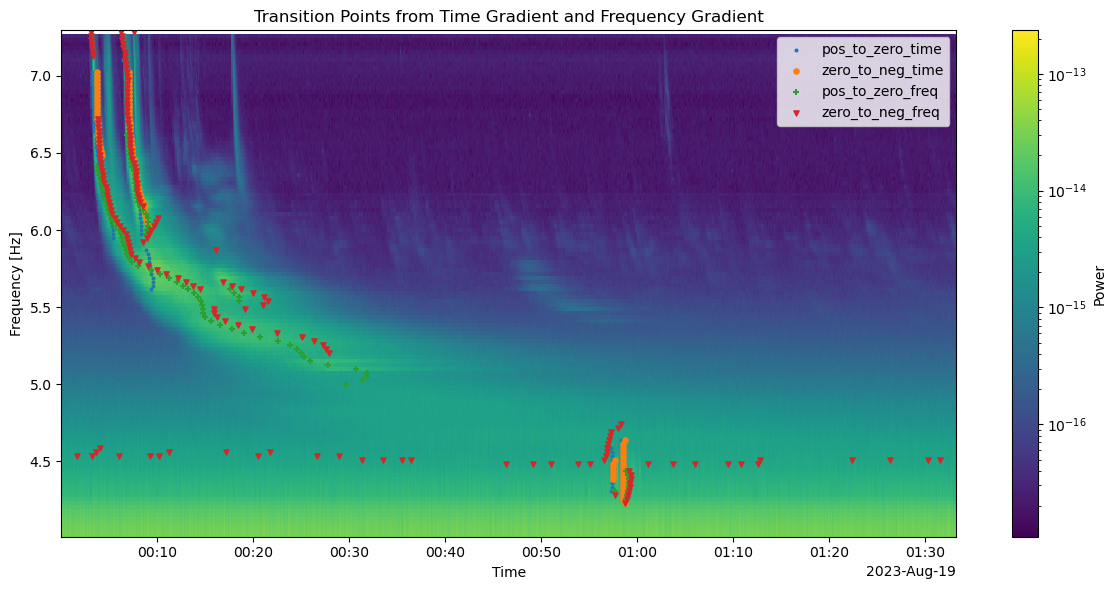

In [441]:
plot_time_and_freq_transition_points(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    pos_to_zero_points_time=pos_to_zero_points_time,
    zero_to_neg_points_time=zero_to_neg_points_time,
    pos_to_neg_points_time=pos_to_neg_points_time,
    pos_to_zero_points_freq=pos_to_zero_points_freq,
    zero_to_neg_points_freq=zero_to_neg_points_freq,
    pos_to_neg_points_freq=pos_to_neg_points_freq,
    pos_to_zero_points_all=pos_to_zero_points_all
)

## Transition point as the midpoints within a range of transition

In [577]:
def find_transition_midpoints_in_range(
    grad_img,
    start_level=0.015,
    end_level=-0.015,
    max_gap=100,
    min_gap=5
):
    # Find transition regions from start_level to end_level.

    # Returns: transition_points: list of (middle_time_idx, freq_idx)
    # transition_ranges: list of (start_time_idx, middle_time_idx, end_time_idx, freq_idx)

    transition_points = []
    transition_ranges = []

    n_time = grad_img.shape[0]
    n_freq = grad_img.shape[1]

    # loop through each frequency
    for freq_idx in range(n_freq):
        time_idx = 0
        # scan from left to right in time
        while time_idx < n_time:
            value_now = grad_img[time_idx, freq_idx]
            # check whether this point is a start point
            if value_now >= start_level:
                start_time_idx = time_idx
                end_time_idx = None

                # now search forward for the end point
                search_start = start_time_idx + min_gap
                search_end = start_time_idx + max_gap
                if search_end >= n_time:
                    search_end = n_time - 1

                for next_time_idx in range(search_start, search_end + 1):
                    value_next = grad_img[next_time_idx, freq_idx]
                    # found the end of transition
                    if value_next <= end_level:
                        end_time_idx = next_time_idx
                        break

                # if we found a full transition
                if end_time_idx is not None:
                    middle_time_idx = int((start_time_idx + end_time_idx) / 2)
                    transition_points.append((middle_time_idx, freq_idx))
                    transition_ranges.append((start_time_idx, middle_time_idx, end_time_idx, freq_idx))
                    # jump forward so we do not mark the same transition many times
                    time_idx = end_time_idx + 1
                else:
                    time_idx = time_idx + 1
            else:
                time_idx = time_idx + 1

    return transition_points, transition_ranges

In [533]:
transition_points_time, transition_ranges_time = find_transition_midpoints_in_range(
    grad_img=norm_grad_time_blur,
    start_level=0.0003,
    end_level=-0.0003,
    max_gap=100,
    min_gap=0
)

print("number of transition midpoint points for time:", len(transition_points_time))

number of transition midpoint points for time: 936


In [989]:
def plot_transition_midpoints(
    data_arr_log,
    times_arr,
    freq_log_exp,
    transition_points,
    label_name="transition midpoint"
):
    fig, ax = plt.subplots(figsize=(12, 6))

    Z = data_arr_log[:800].T.astype(float)
    Z = np.nan_to_num(Z, nan=0.0)

    p = ax.pcolormesh(
        times_arr[:800],
        freq_log_exp,
        Z,
        shading="auto",
        norm=LogNorm())
    plt.colorbar(p, ax=ax, label="Power")

    # plot transition points
    if len(transition_points) > 0:

        time_indices = []
        freq_indices = []

        for point in transition_points:
            time_idx = point[0]
            freq_idx = point[1]
            time_indices.append(time_idx)
            freq_indices.append(freq_idx)

        ax.scatter(
            times_arr[:800][time_indices],
            freq_log_exp[freq_indices],
            s=15,
            marker="x",
            label=label_name)

    ax.set_xlabel("Time")
    ax.set_ylabel("Log Frequency [Hz] Exoponent")
    ax.set_title("Transition Midpoints on Original Spectrum")
    ax.legend()
    plt.tight_layout()
    plt.show()

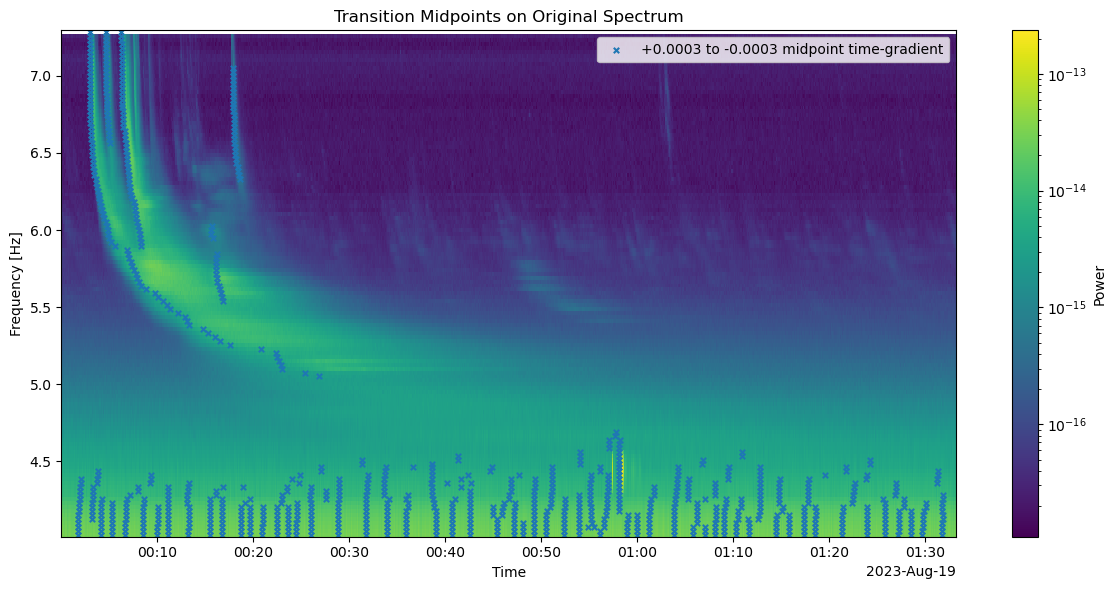

In [565]:
plot_transition_midpoints(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points=transition_points_time,
    label_name="+0.0003 to -0.0003 midpoint time-gradient"
)

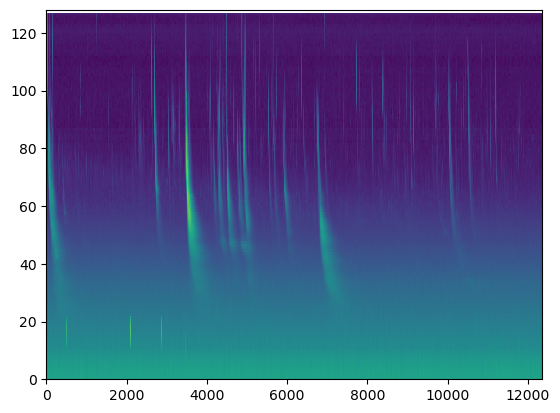

In [457]:
plt.pcolormesh(data_arr_log.T, norm=LogNorm())

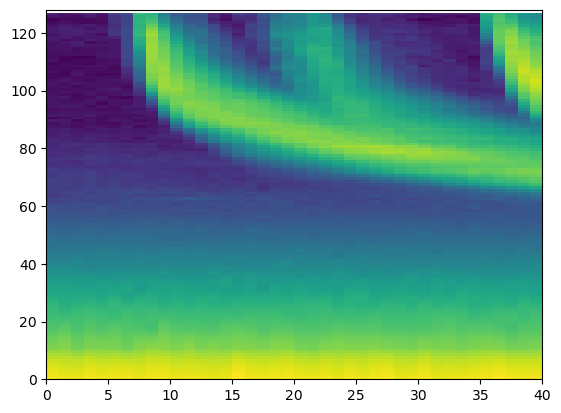

In [463]:
plt.pcolormesh(data_arr_log[20:60].T, norm=LogNorm())

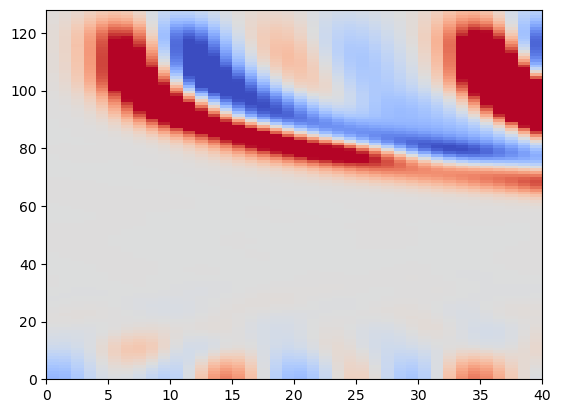

In [499]:
plt.pcolormesh(norm_grad_time_blur[20:60].T, cmap="coolwarm",norm=TwoSlopeNorm(vmin=-0.005, vcenter=0, vmax=0.005))

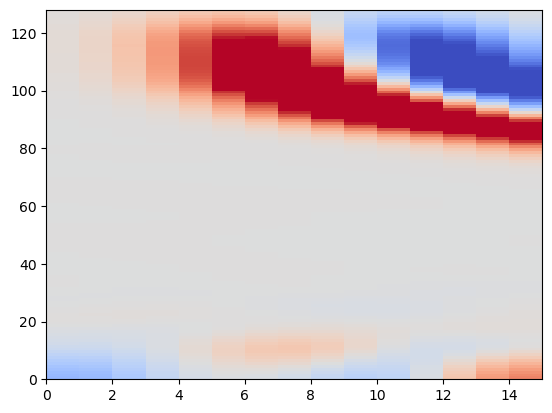

In [487]:
plt.pcolormesh(norm_grad_time_blur[20:35].T, cmap="coolwarm",norm=TwoSlopeNorm(vmin=-0.005, vcenter=0, vmax=0.005))

In [567]:
transition_points_freq, transition_ranges_freq = find_transition_midpoints_in_range(
    grad_img=norm_grad_freq_blur,
    start_level=0.00005,
    end_level=-0.00005,
    max_gap=500,
    min_gap=0
)

print("number of transition midpoint points for freq:", len(transition_points_freq))

number of transition midpoint points for freq: 215


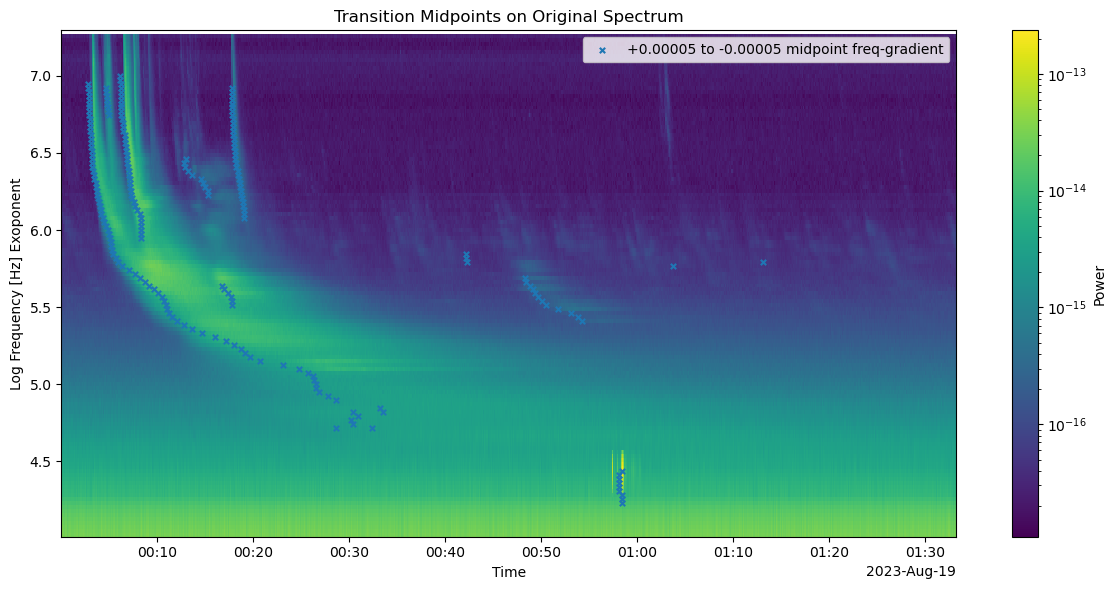

In [991]:
plot_transition_midpoints(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points=transition_points_freq,
    label_name="+0.00005 to -0.00005 midpoint freq-gradient"
)

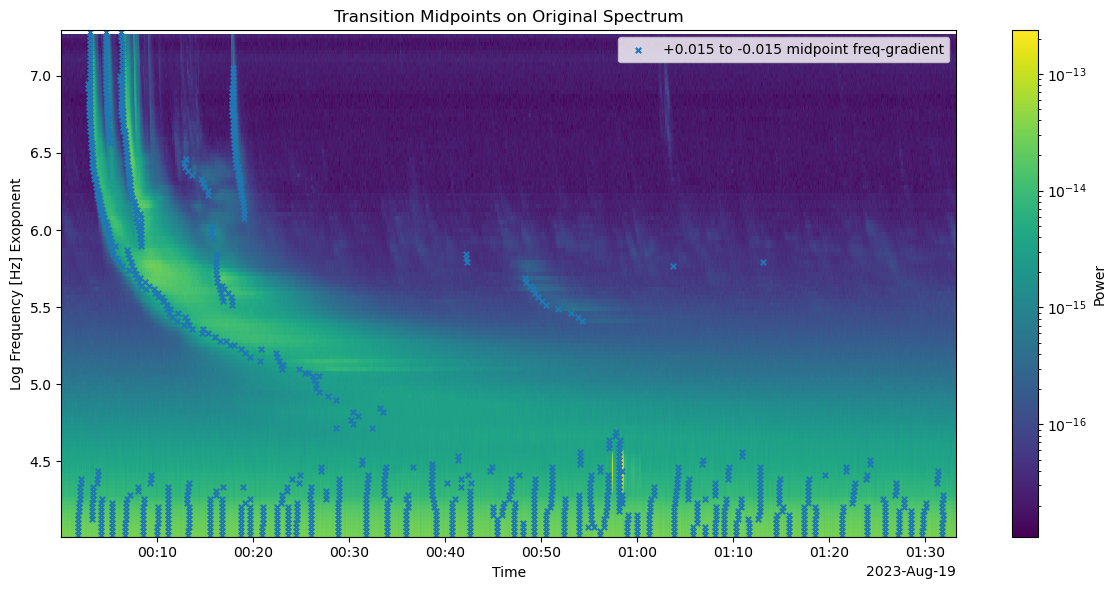

In [992]:
transition_points_all = transition_points_time + transition_points_freq

plot_transition_midpoints(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points=transition_points_all,
    label_name="+0.015 to -0.015 midpoint freq-gradient"
)

In [995]:
def plot_transition_points_time_and_freq(
    data_arr_log,
    times_arr,
    freq_log_exp,
    transition_points_time,
    transition_points_freq
):
    fig, ax = plt.subplots(figsize=(12, 6))
    Z = data_arr_log[:800].T.astype(float)
    Z = np.nan_to_num(Z, nan=0.0)

    p = ax.pcolormesh(
        times_arr[:800],
        freq_log_exp,
        Z,
        shading="auto",
        norm=LogNorm())
    plt.colorbar(p, ax=ax, label="Power")

    # plot time transition points
    if len(transition_points_time) > 0:
        time_idx_time = []
        freq_idx_time = []
        for point in transition_points_time:
            time_idx_time.append(point[0])
            freq_idx_time.append(point[1])

        ax.scatter(
            times_arr[:800][time_idx_time],
            freq_log_exp[freq_idx_time],
            s=18,
            marker="o",
            label="transition_points_time")

    # plot freq transition points
    if len(transition_points_freq) > 0:
        time_idx_freq = []
        freq_idx_freq = []
        for point in transition_points_freq:
            time_idx_freq.append(point[0])
            freq_idx_freq.append(point[1])

        ax.scatter(
            times_arr[:800][time_idx_freq],
            freq_log_exp[freq_idx_freq],
            s=18,
            marker="x",
            label="transition_points_freq")

    ax.set_xlabel("Time")
    ax.set_ylabel("Log Frequency [Hz] Exoponent")
    ax.set_title("Transition Points Time and Freq on Same Plot")
    ax.legend()
    plt.tight_layout()
    plt.show()

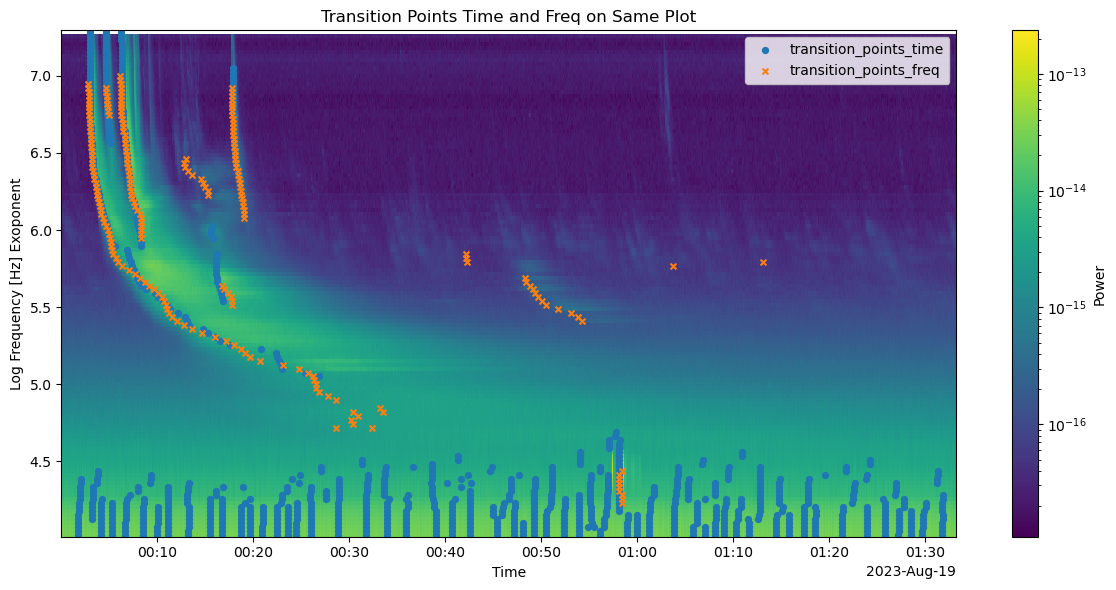

In [997]:
plot_transition_points_time_and_freq(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points_time=transition_points_time,
    transition_points_freq=transition_points_freq
)

## Scan from top to bottom: for each time idx, scan from high freq to low freq

In [667]:
def find_transition_midpoints_top_to_bottom(
    grad_img,
    start_level=0.005,
    end_level=-0.005,
    max_gap=5,
    min_gap=0
):
    # Find transition regions from start_level to end_level,
    # but scan from top to bottom in frequency.

    # Returns:
    # transition_points: list of (time_idx, middle_freq_idx)
    # transition_ranges: list of (time_idx, start_freq_idx, middle_freq_idx, end_freq_idx)

    transition_points = []
    transition_ranges = []
    n_time = grad_img.shape[0]
    n_freq = grad_img.shape[1]

    # loop through each time
    for time_idx in range(n_time):
        freq_idx = 0

        # scan from top to bottom in frequency index
        while freq_idx < n_freq:
            value_now = grad_img[time_idx, freq_idx]

            # check whether this point is a start point
            if value_now >= start_level:
                start_freq_idx = freq_idx
                end_freq_idx = None

                #  search downward for the end point
                search_start = start_freq_idx + min_gap
                search_end = start_freq_idx + max_gap
                if search_end >= n_freq:
                    search_end = n_freq - 1

                for next_freq_idx in range(search_start, search_end + 1):
                    value_next = grad_img[time_idx, next_freq_idx]
                    # found end point
                    if value_next <= end_level:
                        end_freq_idx = next_freq_idx
                        break

                # found a full transition
                if end_freq_idx is not None:
                    middle_freq_idx = int((start_freq_idx + end_freq_idx) / 2)
                    transition_points.append((time_idx, middle_freq_idx))
                    transition_ranges.append((time_idx, start_freq_idx, middle_freq_idx, end_freq_idx))
                    # jump forward to aviod marking the same transition many times
                    freq_idx = end_freq_idx + 1

                else:
                    freq_idx = freq_idx + 1
            else:
                freq_idx = freq_idx + 1

    return transition_points, transition_ranges

In [673]:
transition_points_top_bottom, transition_ranges_top_bottom = find_transition_midpoints_top_to_bottom(
    grad_img=norm_grad_freq_blur,
    start_level=0.0001,
    end_level=-0.0001,
    max_gap=10,
    min_gap=0
)

len(transition_points_top_bottom)

529

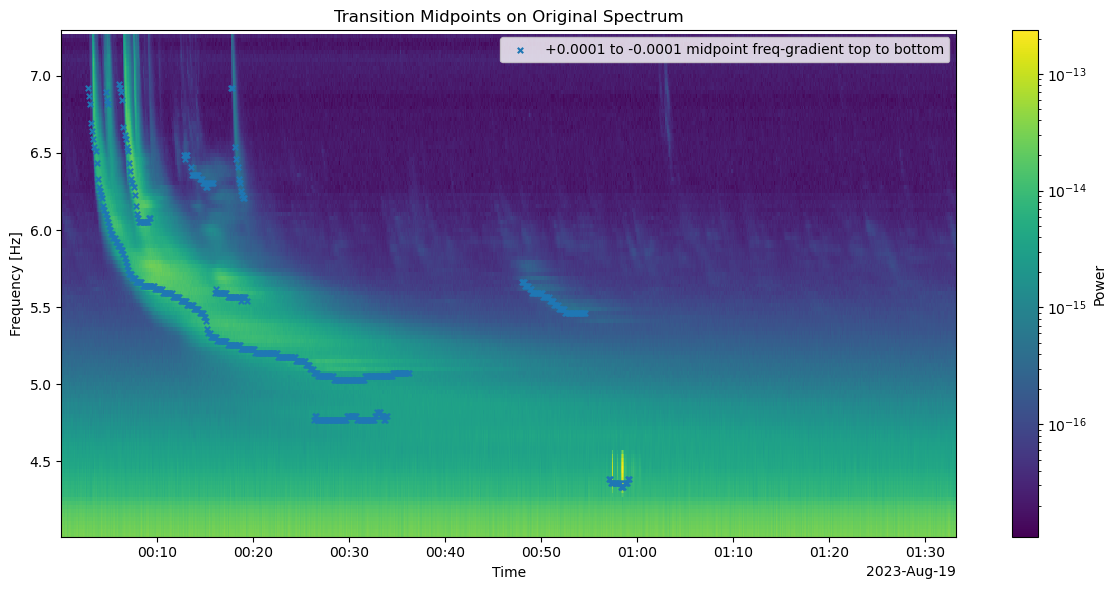

In [675]:
plot_transition_midpoints(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points=transition_points_top_bottom,
    label_name="+0.0001 to -0.0001 midpoint freq-gradient top to bottom"
)

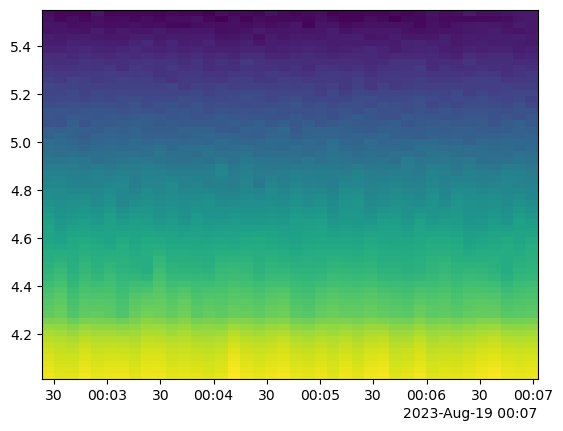

In [635]:
plt.pcolormesh(times_arr[20:60], freq_log_exp[:60], data_arr_log[20:60, :60].T, norm=LogNorm())

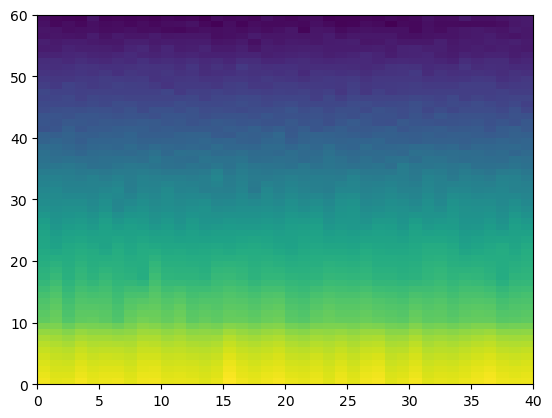

In [637]:
plt.pcolormesh(data_arr_log[20:60, :60].T, norm=LogNorm())

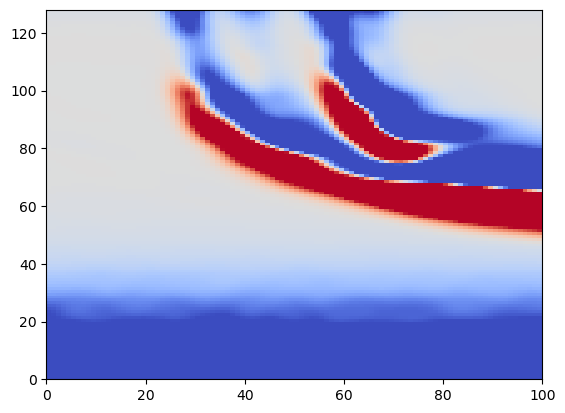

In [661]:
plt.pcolormesh(norm_grad_freq_blur[:100].T, cmap="coolwarm",norm=TwoSlopeNorm(vmin=-0.005, vcenter=0, vmax=0.005))

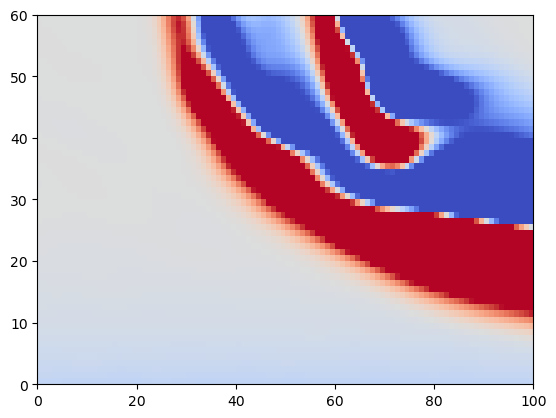

In [663]:
plt.pcolormesh(norm_grad_freq_blur[:100, 40:100].T, cmap="coolwarm",norm=TwoSlopeNorm(vmin=-0.005, vcenter=0, vmax=0.005))

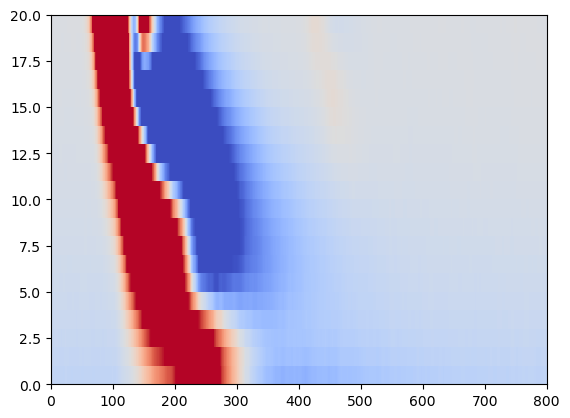

In [665]:
plt.pcolormesh(norm_grad_freq_blur[:, 40:60].T, cmap="coolwarm",norm=TwoSlopeNorm(vmin=-0.005, vcenter=0, vmax=0.005))

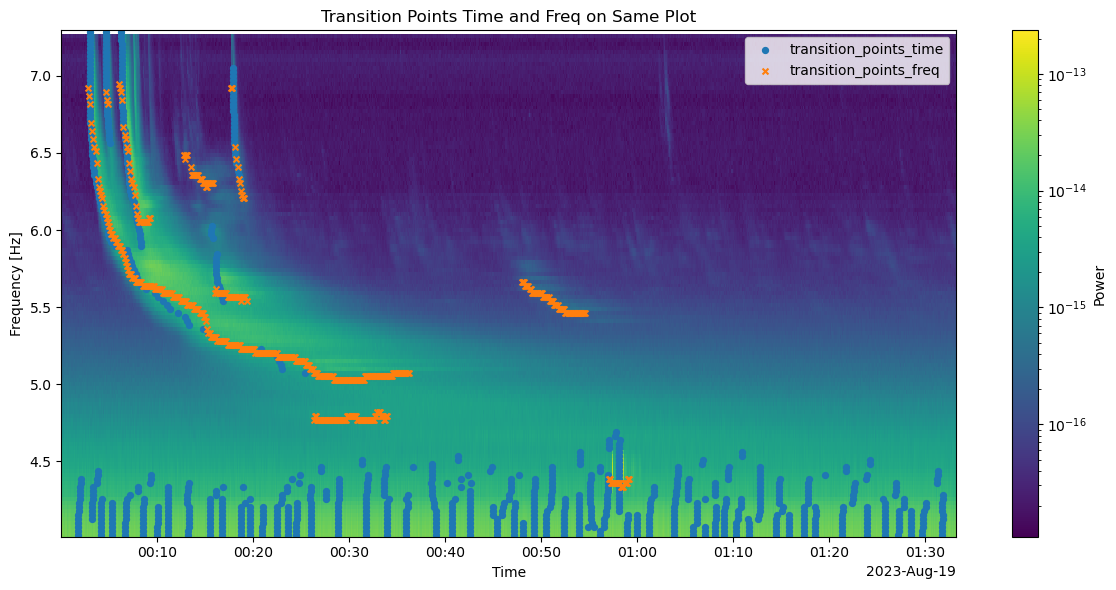

In [677]:
plot_transition_points_time_and_freq(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points_time=transition_points_time,
    transition_points_freq=transition_points_top_bottom
)

## units in freq

In [775]:
freq_gap, times_gap_UNX = find_unit(freq_log_exp, times_arr)
print(f'moving 1 pixel or 1 index in frequency direction = moving {freq_gap} in log-frequency value')
print(f'moving 1 pixel/index in time direction = {times_gap_UNX} seconds')

moving 1 pixel or 1 index in frequency direction = moving 0.025665673683947787 in log-frequency value
moving 1 pixel/index in time direction = 6.990724086761475 seconds


In [869]:
def convert_unit_to_pixel(freq_log_exp, times_arr, freq_exp_difference, time_seconds):
    # Convert real units (freq exp, sec) back into pixel or index.
    # what currently each pixel means
    freq_gap, times_gap_UNX = find_unit(freq_log_exp, times_arr)

    # convert real difference into pixel difference
    freq_pixel_difference = int(freq_exp_difference / freq_gap)
    print('freq')
    print(freq_exp_difference)
    print(freq_gap)
    print(freq_pixel_difference)
    print()
    time_pixel_difference = int(time_seconds / times_gap_UNX)
    print('time')
    print(time_seconds)
    print(times_gap_UNX)
    print(time_pixel_difference)
    print()

    return freq_pixel_difference, time_pixel_difference

In [843]:
def find_transition_midpoints_top_to_bottom_real_unit(grad_img,
    start_level=0.005,
    end_level=-0.005,
    max_gap_freq_exp_real=0.25,
    min_gap_freq_exp_real=0):
    # start/end level as the gradient of pixel power intensity
    # max_gap_freq_exp_real = the maximum range of transition in the unit of freq_log_exponent
    max_gap_pixel, time_place_holder = convert_unit_to_pixel(freq_log_exp, times_arr, freq_exp_difference=max_gap_freq_exp_real, time_seconds=0)
    min_gap_pixel, time_place_holder = convert_unit_to_pixel(freq_log_exp, times_arr, freq_exp_difference=min_gap_freq_exp_real, time_seconds=0)

    # print(max_gap_pixel)
    
    return find_transition_midpoints_top_to_bottom(
        grad_img,
        start_level=0.005,
        end_level=-0.005,
        max_gap=max_gap_pixel,
        min_gap=min_gap_pixel)

In [877]:
transition_points_top_bottom_real, transition_ranges_top_bottom_real = find_transition_midpoints_top_to_bottom_real_unit(norm_grad_freq_blur,
    start_level=0.005,
    end_level=-0.005,
    max_gap_freq_exp_real=0.25,
    min_gap_freq_exp_real=0)

freq
0.25
0.025665673683947787
9

time
0
6.990724086761475
0

freq
0
0.025665673683947787
0

time
0
6.990724086761475
0



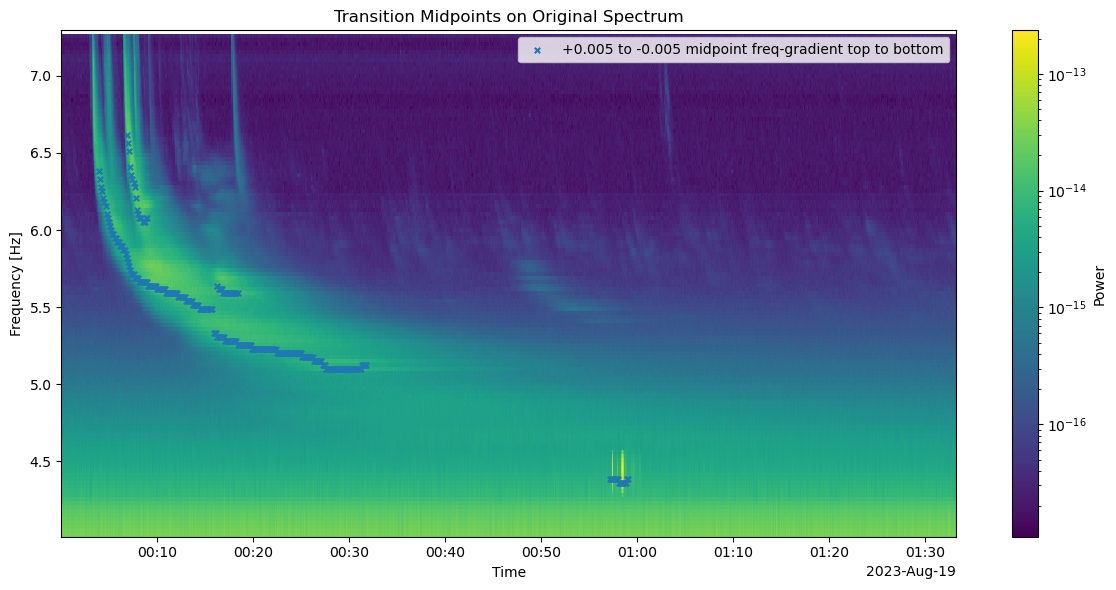

In [879]:
plot_transition_midpoints(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points=transition_points_top_bottom_real,
    label_name="+0.005 to -0.005 midpoint freq-gradient top to bottom"
)

## units in time

In [853]:
def find_transition_midpoints_in_range_real(
    grad_img=norm_grad_time_blur,
    start_level=0.0003,
    end_level=-0.0003,
    max_gap_time_real=700,
    min_gap_time_real=0):
    
    # max_gap_freq_exp_real = the maximum range of transition in the unit of secs
    freq_place_holder, max_gap_pixel = convert_unit_to_pixel(freq_log_exp, times_arr, freq_exp_difference=0, time_seconds=max_gap_time_real)
    freq_place_holder, min_gap_pixel = convert_unit_to_pixel(freq_log_exp, times_arr, freq_exp_difference=0, time_seconds=min_gap_time_real)

    return find_transition_midpoints_in_range(
        grad_img=norm_grad_time_blur,
        start_level=0.0003,
        end_level=-0.0003,
        max_gap=max_gap_pixel,
        min_gap=min_gap_pixel)

In [881]:
transition_points_left_right_real, transition_ranges_left_right_real = find_transition_midpoints_in_range_real(
    grad_img=norm_grad_time_blur,
    start_level=0.0003,
    end_level=-0.0003,
    max_gap_time_real=700,
    min_gap_time_real=0)

freq
0
0.025665673683947787
0

time
700
6.990724086761475
100

freq
0
0.025665673683947787
0

time
0
6.990724086761475
0



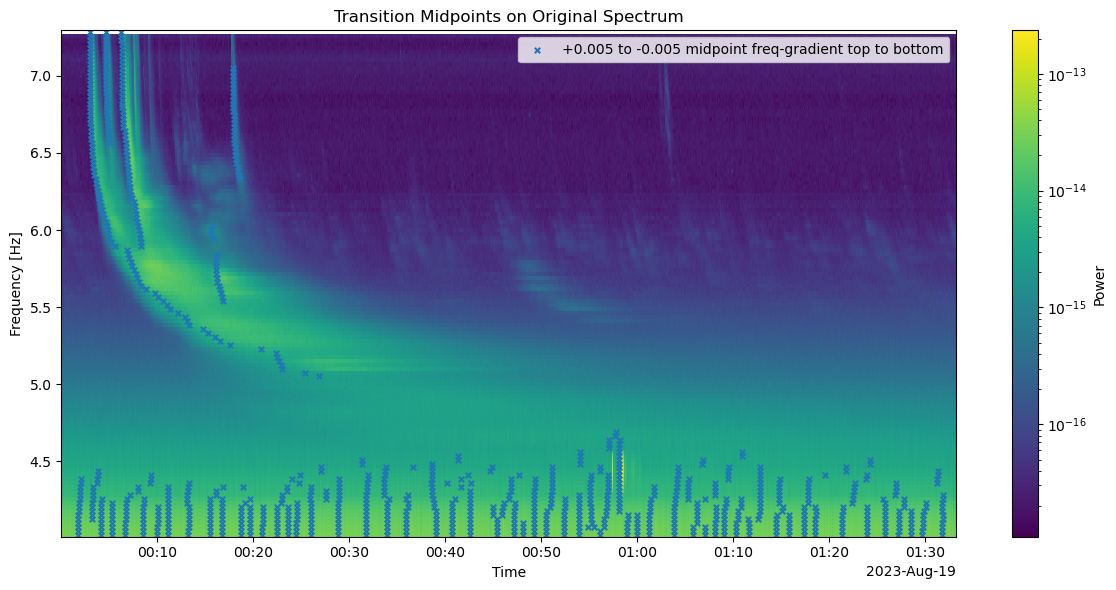

In [885]:
plot_transition_midpoints(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    transition_points=transition_points_left_right_real,
    label_name="+0.005 to -0.005 midpoint freq-gradient top to bottom"
)

## Extract the most dominant line

In [741]:
def group_nearby_points(point_list, time_gap=8, freq_gap=3):
    # remove duplicate points
    point_set = set(point_list)

    visited = set()
    groups = []

    for point in point_set:
        if point in visited:
            continue
        # start a new group
        current_group = []
        potential_stack = [point]
        visited.add(point)

        while len(potential_stack) > 0:
            current_point = potential_stack.pop()
            current_group.append(current_point)

            time_idx = current_point[0]
            freq_idx = current_point[1]

            # check nearby points
            for time_diff in range(-time_gap, time_gap + 1):
                for freq_diff in range(-freq_gap, freq_gap + 1):
                    new_time_idx = time_idx + time_diff
                    new_freq_idx = freq_idx + freq_diff
                    new_point = (new_time_idx, new_freq_idx)

                    if new_point in point_set and new_point not in visited:
                        visited.add(new_point)
                        potential_stack.append(new_point)

        groups.append(current_group)

    return groups

In [761]:
def choose_dominant_group(groups, freq_log_exp=None, min_freq_value_exp=None):
    # min_freq_value_exp: removes very low-frequency noise points; the minimum freq exp, everything below cut off, e.g. 4.8

    best_group = None
    best_score = -1

    for group in groups:     
        cleaned_group = []
        for point in group:
            time_idx = point[0]
            freq_idx = point[1]
            # remove low-frequency noise
            if freq_log_exp is not None and min_freq_value_exp is not None:
                real_freq_exp = freq_log_exp[freq_idx]
                if real_freq_exp >= min_freq_value_exp:
                    cleaned_group.append(point)
            else:
                cleaned_group.append(point)
        if len(cleaned_group) == 0:
            continue

        # time_indices = [point[0] for point in cleaned_group]
        # freq_indices = [point[1] for point in cleaned_group]
        # time_span = max(time_indices) - min(time_indices)
        # freq_span = max(freq_indices) - min(freq_indices)
        
        # score = len of one group
        score = len(cleaned_group) # + freq_span + time_span
        if score > best_score:
            best_score = score
            best_group = cleaned_group

    return best_group

In [765]:
def plot_dominant_burst_line(
    data_arr_log,
    times_arr,
    freq_log_exp,
    dominant_group
):
    fig, ax = plt.subplots(figsize=(12, 6))
    Z = data_arr_log[:800].T.astype(float)
    Z = np.nan_to_num(Z, nan=0.0)
    p = ax.pcolormesh(
        times_arr[:800],
        freq_log_exp,
        Z,
        shading="auto",
        norm=LogNorm())
    plt.colorbar(p, ax=ax, label="Power")

    # plot all points in dominant group
    group_time = []
    group_freq = []

    for point in dominant_group:
        group_time.append(point[0])
        group_freq.append(point[1])

    ax.scatter(
        times_arr[:800][group_time],
        freq_log_exp[group_freq],
        s=10,
        label="dominant group points")

    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title("Extracted Most Dominant Burst")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [755]:
# combine two transition point sets
all_transition_points = list(transition_points_time) + list(transition_points_top_bottom)

# group nearby points
groups = group_nearby_points(
    point_list=all_transition_points,
    time_gap=5,
    freq_gap=5
)

print("number of groups:", len(groups))

number of groups: 74


In [763]:
dominant_group = choose_dominant_group(
    groups=groups,
    freq_log_exp=freq_log_exp,
    min_freq_value_exp=4.8)

print("number of points in dominant group:", len(dominant_group))

number of points in dominant group: 368


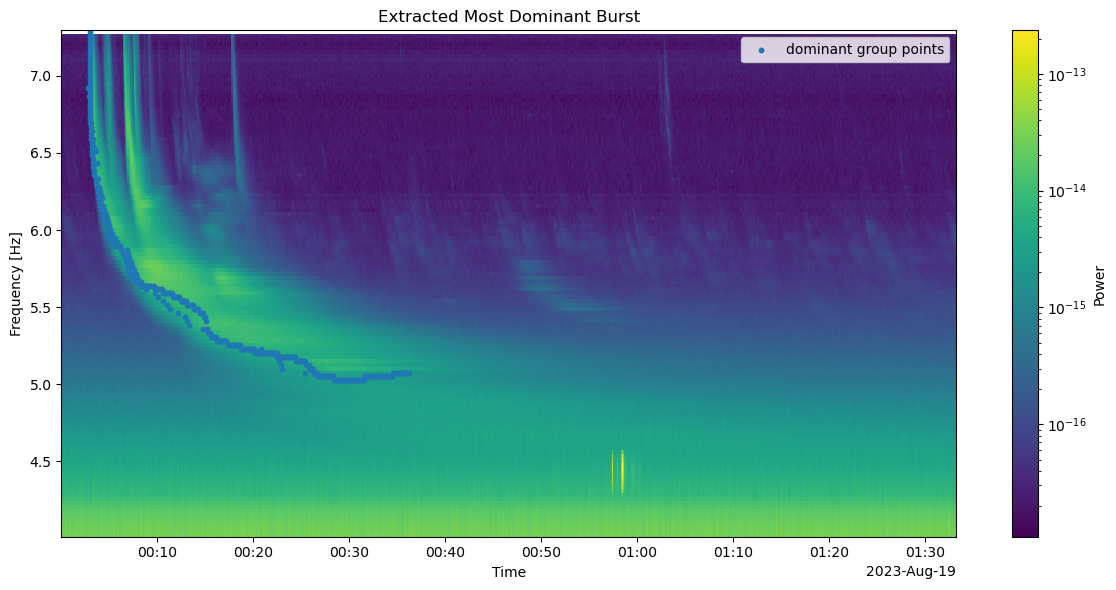

In [767]:
plot_dominant_burst_line(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    dominant_group=dominant_group)

## all donimant lines

In [920]:
def keep_long_enough_groups(
    groups,
    min_points=30,
    min_freq_span=10,
    min_time_span=10,
    freq_log_exp=None,
    min_freq_value=None
):
    # min_points: group must have at least this many points
    # min_freq_span: group must cover at least this many frequency indices
    # min_time_span: group must cover at least this many time indices
        # no need probably, since some bursts are very very fast
    # min_freq_value: removes very low-frequency noise points. e.g. below 4.8 in freq exp

    long_groups = []
    for group in groups:
        cleaned_group = []
        for point in group:
            time_idx = point[0]
            freq_idx = point[1]
            # clean low background noise
            if freq_log_exp is not None and min_freq_value is not None:
                real_freq = freq_log_exp[freq_idx]
                if real_freq >= min_freq_value:
                    cleaned_group.append(point)
            else:
                cleaned_group.append(point)
        if len(cleaned_group) == 0:
            continue
            
        time_indices = []
        freq_indices = []
        for point in cleaned_group:
            time_indices.append(point[0])
            freq_indices.append(point[1])
        num_points = len(cleaned_group)
        time_span = max(time_indices) - min(time_indices)
        freq_span = max(freq_indices) - min(freq_indices)
        # check if group is long enough
        if num_points >= min_points and freq_span >= min_freq_span: # and time_span >= min_time_span:
            long_groups.append(cleaned_group)

    return long_groups

In [922]:
def plot_all_long_burst_lines(
    data_arr_log,
    times_arr,
    freq_log_exp,
    long_groups,
    all_lines
):
    fig, ax = plt.subplots(figsize=(12, 6))
    Z = data_arr_log[:800].T.astype(float)
    Z = np.nan_to_num(Z, nan=0.0)
    p = ax.pcolormesh(
        times_arr[:800],
        freq_log_exp,
        Z,
        shading="auto",
        norm=LogNorm())
    plt.colorbar(p, ax=ax, label="Power")

    # plot each long group 
    for i in range(len(long_groups)):
        group = long_groups[i]
        line_time_indices = all_lines[i][0]
        line_freq_indices = all_lines[i][1]
        # group points
        group_time = []
        group_freq = []
        for point in group:
            group_time.append(point[0])
            group_freq.append(point[1])
        ax.scatter(
            times_arr[:800][group_time],
            freq_log_exp[group_freq],
            s=8,
            alpha=0.5,
            label="group " + str(i)
        )

        # extracted line
        # ax.plot(
        #     times_arr[:800][line_time_indices],
        #     freq_log_exp[line_freq_indices],
        #     linewidth=2.5,
        #     label="line " + str(i)
        # )

    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency [Hz]")
    ax.set_title("All Long Enough Burst Lines")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [924]:
# combine your transition points
all_transition_points = list(transition_points_time) + list(transition_points_top_bottom)

# group nearby transition points
groups = group_nearby_points(
    point_list=all_transition_points,
    time_gap=8,
    freq_gap=3
)

print("number of total groups:", len(groups))

number of total groups: 58


In [926]:
long_groups = keep_long_enough_groups(
    groups=groups,
    min_points=30,
    min_freq_span=10,
    min_time_span=10,
    freq_log_exp=freq_log_exp,
    min_freq_value=4.8
)

print("number of long enough groups:", len(long_groups))

number of long enough groups: 5


In [928]:
img_original = data_arr_log[:800].astype(float)

all_lines = make_lines_from_all_groups(
    long_groups=long_groups,
    data_img=img_original
)

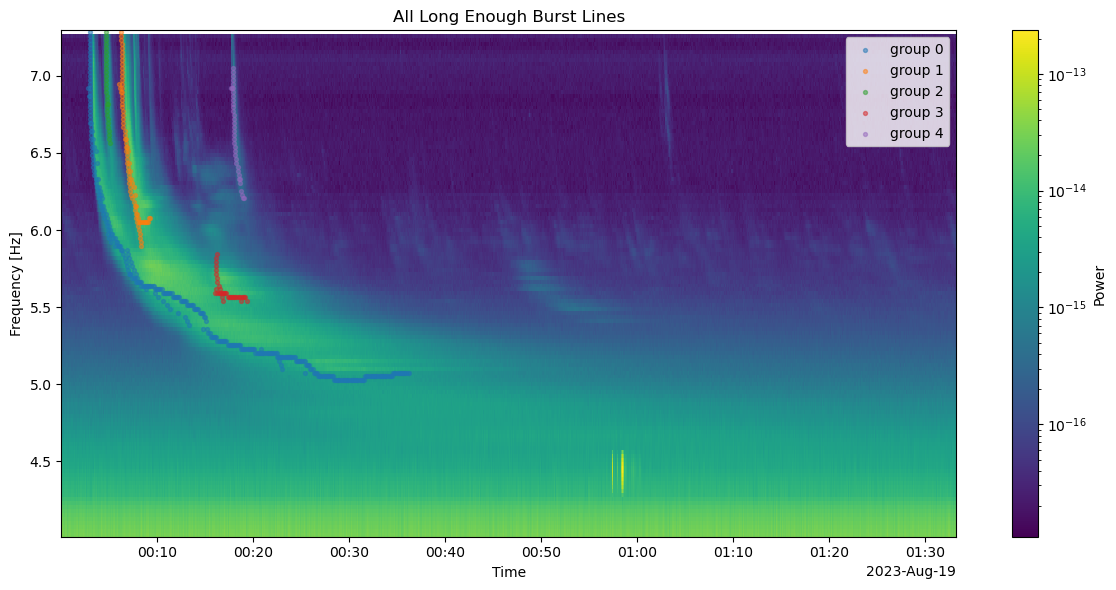

In [930]:
plot_all_long_burst_lines(
    data_arr_log=data_arr_log,
    times_arr=times_arr,
    freq_log_exp=freq_log_exp,
    long_groups=long_groups,
    all_lines=all_lines
)

### Trying run the gradient on the spectrum for the whole day

In [938]:
img_original_with_nan = data_arr_log.astype(float)
img = np.nan_to_num(img_original_with_nan, nan=0.0)

blur_sigma = 2.5

grad_freq_all = np.gradient(img, axis=1)   # frequency-index direction
grad_time_all = np.gradient(img, axis=0)   # time-index direction

norm_grad_freq_all = grad_freq_all / np.max(np.abs(grad_freq_all))
norm_grad_time_all = grad_time_all / np.max(np.abs(grad_time_all))

norm_grad_freq_blur_all = gaussian_filter(norm_grad_freq_all, sigma=blur_sigma)
norm_grad_time_blur_all = gaussian_filter(norm_grad_time_all, sigma=blur_sigma)
# norm_grad_freq_blur = norm_grad_freq
# norm_grad_time_blur = norm_grad_time

print("img shape:", img.shape)
print("norm_grad_freq_blur shape:", norm_grad_freq_blur_all.shape)
print("norm_grad_time_blur shape:", norm_grad_time_blur_all.shape)

img shape: (12359, 128)
norm_grad_freq_blur shape: (12359, 128)
norm_grad_time_blur shape: (12359, 128)


7.796045922741213e-05


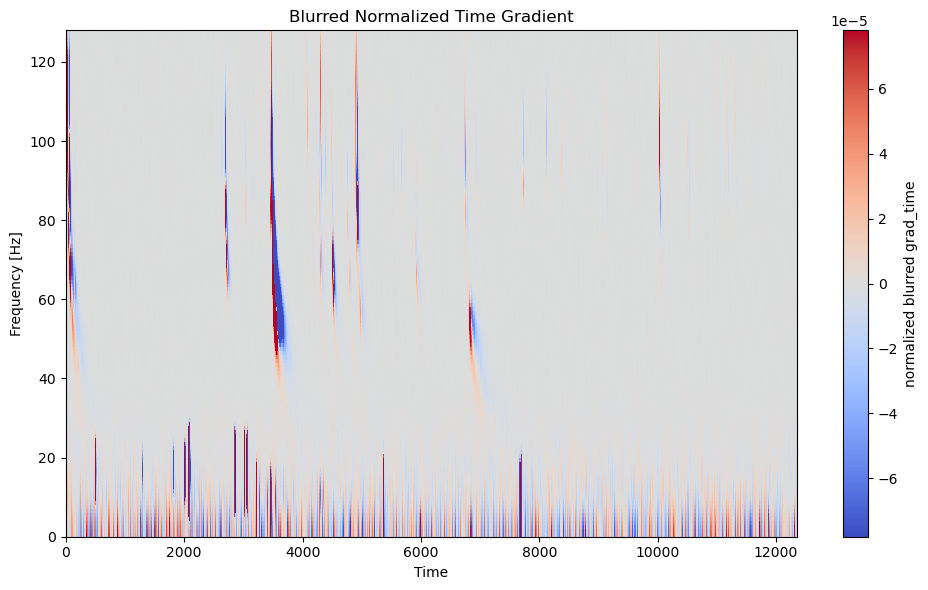

In [942]:
# time
v = np.nanpercentile(np.abs(norm_grad_time_blur_all), 99)
print(v)

fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(
    # times_arr,
    # freq_log_exp,
    norm_grad_time_blur_all.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)

plt.colorbar(p, ax=ax, label="normalized blurred grad_time")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.title("Blurred Normalized Time Gradient")
plt.tight_layout()
plt.show()

0.0008620134615763953


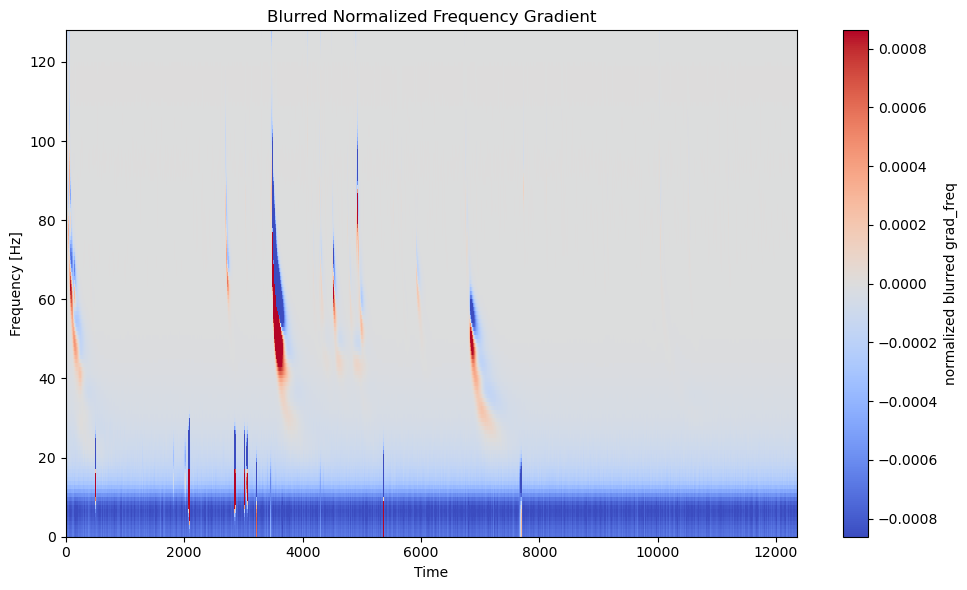

In [944]:
# freq

v = np.nanpercentile(np.abs(norm_grad_freq_blur_all), 99)
print(v)

fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(
    # times_arr,
    # freq_log_exp,
    norm_grad_freq_blur_all.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)

plt.colorbar(p, ax=ax, label="normalized blurred grad_freq")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.title("Blurred Normalized Frequency Gradient")
plt.tight_layout()
plt.show()

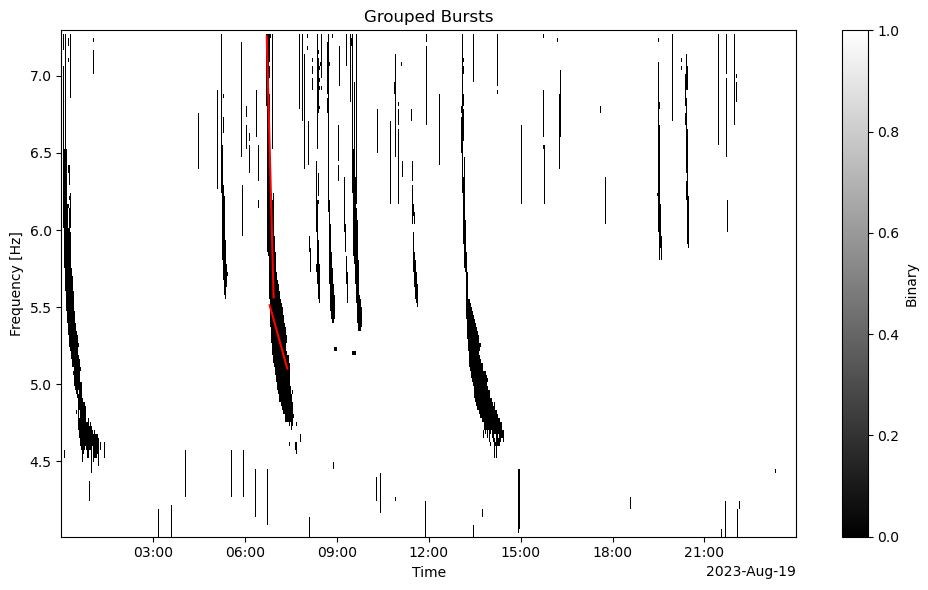

In [712]:
plot_bmap(times_arr, freq_log_exp, bmap, lines[2:4])

In [710]:
lines

[((60, 142), (126, 27)),
 ((19, 582), (45, 176)),
 ((60, 3568), (126, 3453)),
 ((42, 3799), (58, 3502)),
 ((60, 3564), (126, 3450)),
 ((26, 3945), (59, 3516)),
 ((60, 3610), (126, 3513)),
 ((21, 4026), (57, 3504)),
 ((60, 4322), (125, 4221)),
 ((20, 4102), (39, 3750)),
 ((60, 4333), (125, 4220)),
 ((20, 4123), (25, 4020)),
 ((60, 5005), (126, 4891)),
 ((54, 5049), (59, 4960)),
 ((60, 5007), (126, 4892)),
 ((54, 5049), (59, 4961)),
 ((60, 5012), (126, 4897)),
 ((53, 5051), (58, 4964)),
 ((60, 6828), (125, 6716)),
 ((42, 7049), (56, 6812)),
 ((60, 6831), (126, 6716)),
 ((25, 7299), (57, 6810)),
 ((60, 6832), (108, 6750)),
 ((23, 7393), (59, 6807))]

In [700]:
bmap.shape

(12359, 128)

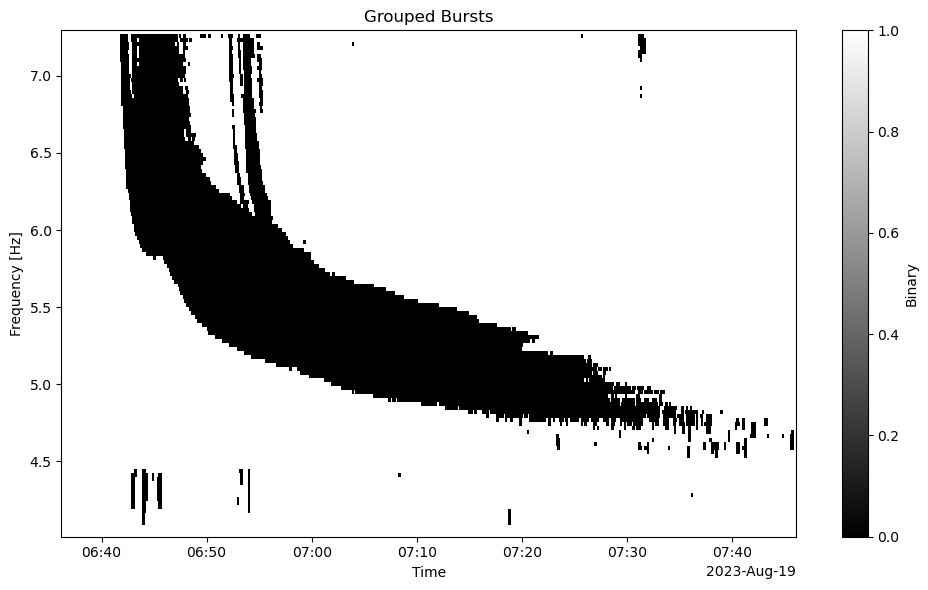

In [979]:
plot_bmap(times_arr[3400:4000], freq_log_exp, bmap[3400:4000])

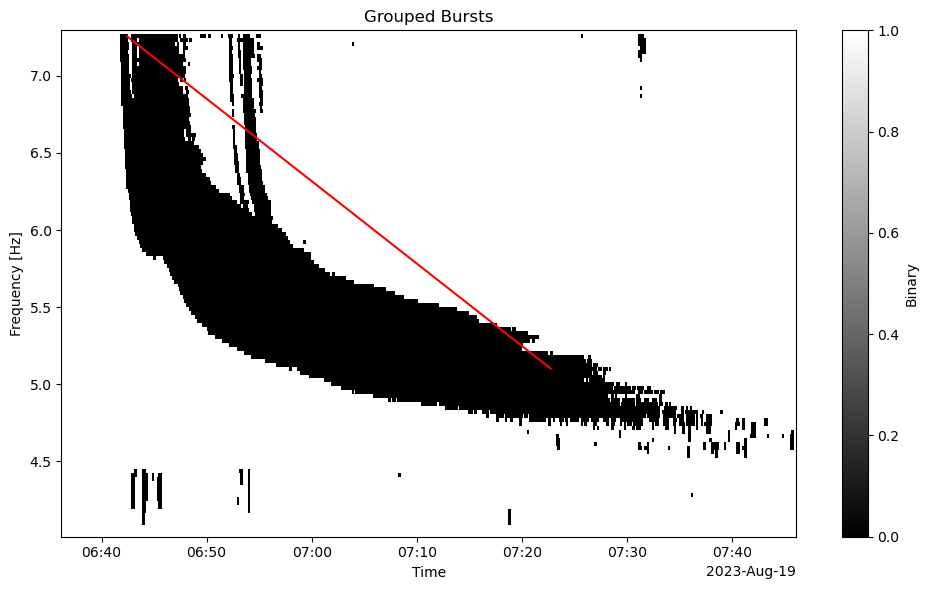

In [981]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap[3400:4000].T
t = times_arr[3400:4000]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

(x0_low, y0_low), (x1_low, y1_low) = lines[3]
(x0_high, y0_high), (x1_high, y1_high) = lines[2]
(x0, y0), (x1, y1) = (x0_low, y0_low), (x1_high, y1_high)

t0, t1 = times_arr[3000:4000][y0-3000], times_arr[3000:4000][y1-3000]
f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

## Gradient new slice

In [969]:
img_original_with_nan = data_arr_log[3400:4000].astype(float)
img = np.nan_to_num(img_original_with_nan, nan=0.0)

blur_sigma = 2.5

grad_freq_slice2 = np.gradient(img, axis=1)   # frequency-index direction
grad_time_slice2 = np.gradient(img, axis=0)   # time-index direction

norm_grad_freq_slice2 = grad_freq_slice2 / np.max(np.abs(grad_freq_slice2))
norm_grad_time_slice2 = grad_time_slice2 / np.max(np.abs(grad_time_slice2))

norm_grad_freq_blur_slice2 = gaussian_filter(norm_grad_freq_slice2, sigma=blur_sigma)
norm_grad_time_blur_slice2 = gaussian_filter(norm_grad_time_slice2, sigma=blur_sigma)
# norm_grad_freq_blur = norm_grad_freq
# norm_grad_time_blur = norm_grad_time

print("img shape:", img.shape)
print("norm_grad_freq_blur shape:", norm_grad_freq_blur_slice2.shape)
print("norm_grad_time_blur shape:", norm_grad_time_blur_slice2.shape)

img shape: (600, 128)
norm_grad_freq_blur shape: (600, 128)
norm_grad_time_blur shape: (600, 128)


0.040379344341323196


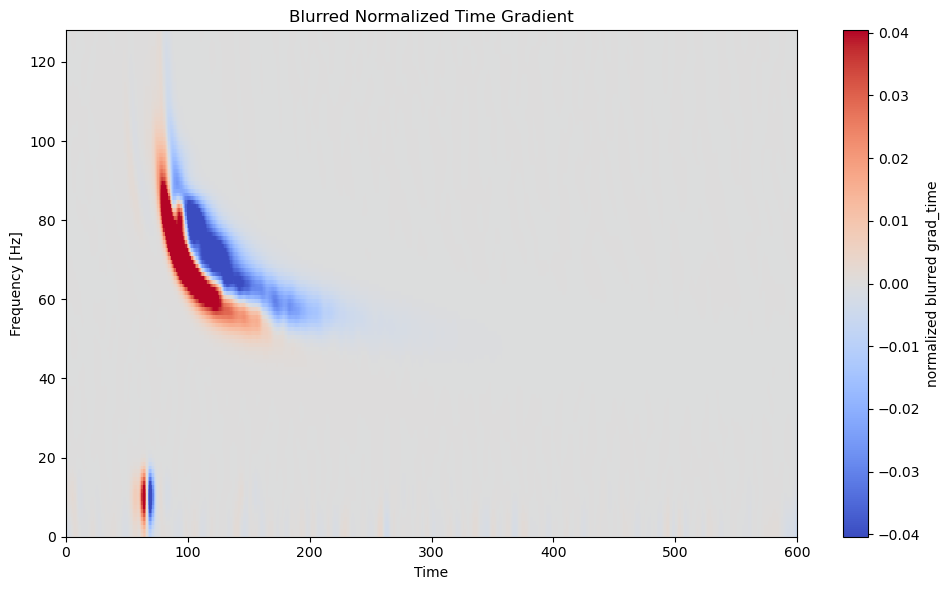

In [971]:
# time
v = np.nanpercentile(np.abs(norm_grad_time_blur_slice2), 99)
print(v)

fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(
    # times_arr,
    # freq_log_exp,
    norm_grad_time_blur_slice2.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)

plt.colorbar(p, ax=ax, label="normalized blurred grad_time")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.title("Blurred Normalized Time Gradient")
plt.tight_layout()
plt.show()

0.20408389750095743


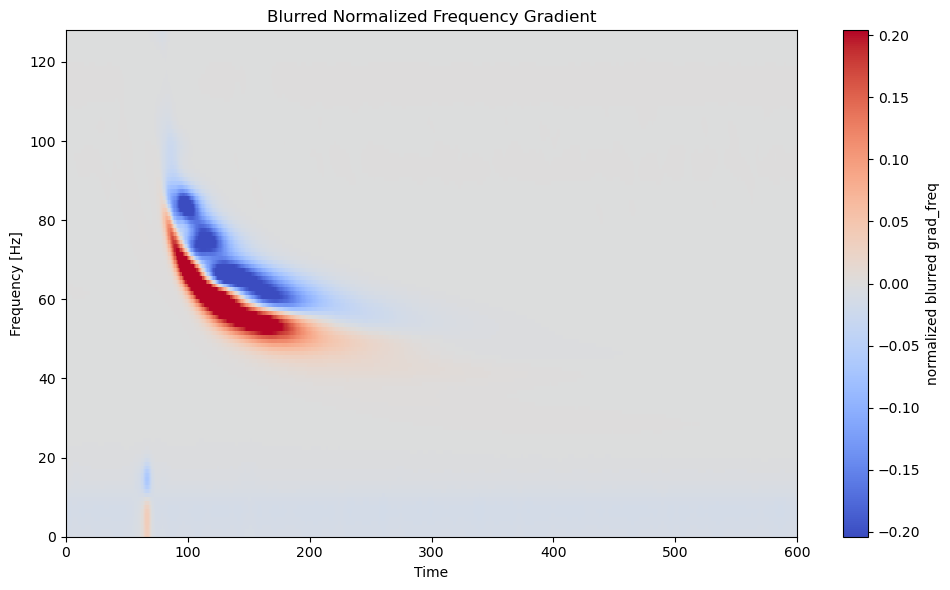

In [973]:
# freq

v = np.nanpercentile(np.abs(norm_grad_freq_blur_slice2), 99)
print(v)

fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(
    # times_arr,
    # freq_log_exp,
    norm_grad_freq_blur_slice2.T,
    shading="auto",
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)

plt.colorbar(p, ax=ax, label="normalized blurred grad_freq")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.title("Blurred Normalized Frequency Gradient")
plt.tight_layout()
plt.show()

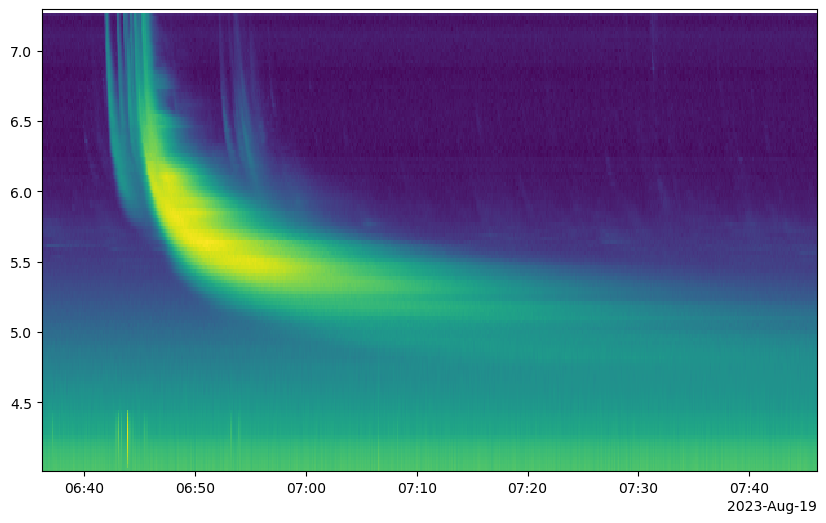

In [975]:
plt.subplots(figsize=(10, 6))
plt.pcolormesh(times_arr[3400:4000], freq_log_exp, data_arr_log[3400:4000].T, norm=LogNorm())

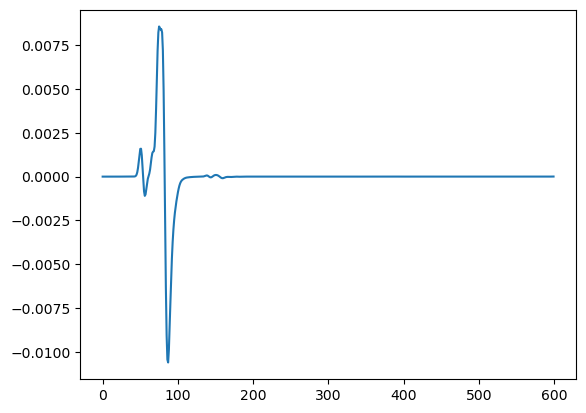

In [1021]:
plt.plot(norm_grad_time_blur_slice2[:, 100])
plt.show()

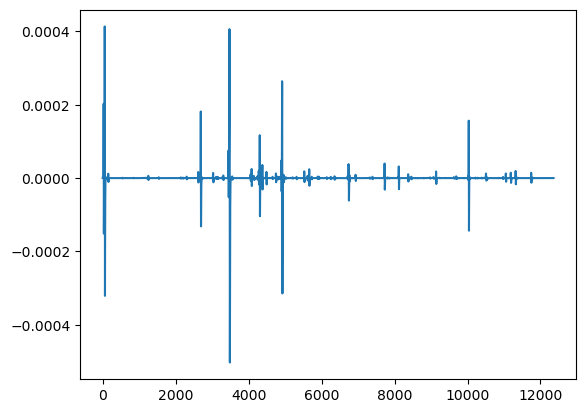

In [1023]:
plt.plot(norm_grad_time_blur_all[:, 100])
plt.show()

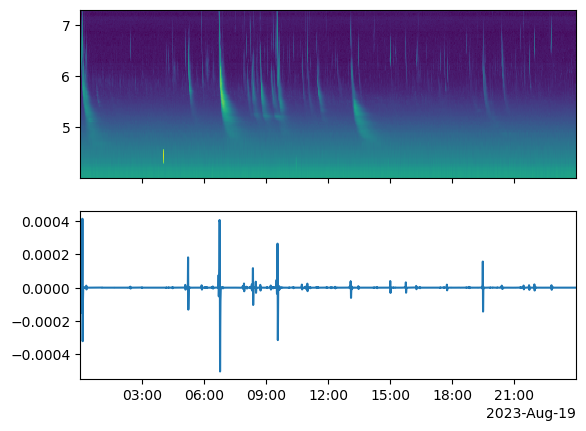

In [1031]:
fig, ax = plt.subplots(nrows = 2, sharex = True)
ax[0].pcolormesh(times_arr, freq_log_exp, data_arr_log.T, norm=LogNorm())
ax[1].plot(times_arr, norm_grad_time_blur_all[:, 100])
plt.show()